### **Notebook #4**

# Group 2: Luca Milani, Marta Laskowska, Monika Kaczorowska
## EDA - Stock Price Data

### Libraries

In [117]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import math
import re
import requests
import bs4 as bs
import yfinance as yf
import datetime
from scipy.stats import norm
from collections import Counter


from ipywidgets import interact, IntSlider, Checkbox
from functools import lru_cache
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option('display.max_colwidth', None)

### Dataset Preparation

In [118]:
def load_excel_sheets_except_request_table(
    file_path: str,
    date_col: str = "Name",
    skip_sheets=("REQUEST_TABLE",)
) -> pd.DataFrame:
    """
    Read all sheets from an Excel file (except specific ones)
    and merge them on a shared key column (e.g. 'Name').

    Adds the sheet name to each column (e.g., 'HSBC - PRICE INDEX (Sheet1)').
    """

    # Read all sheets into a dict: {sheet_name: DataFrame}
    book = pd.read_excel(file_path, sheet_name=None, engine="openpyxl")

    frames = []
    for sheet_name, df in book.items():
        if sheet_name in skip_sheets or df.empty:
            continue

        # Skip if the key column is missing
        if date_col not in df.columns:
            continue

        df = df.copy()

        # Convert the merge key to datetime (if applicable)
        df[date_col] = pd.to_datetime(df[date_col], errors="ignore")

        # Rename columns to include the sheet name (except the merge key)
        df.columns = [
            col if col == date_col else f"{col.strip()} ({sheet_name})"
            for col in df.columns
        ]

        frames.append(df)

    if not frames:
        return pd.DataFrame()  # nothing usable

    # Merge all sheets on the key column (outer join to keep all rows)
    merged_df = frames[0]
    for other_df in frames[1:]:
        merged_df = pd.merge(
            merged_df,
            other_df,
            on=date_col,
            how="outer",
            suffixes=("", "_dup")
        )

    return merged_df

In [119]:
def get_excel_sheet_names(file_path: str, skip_sheets=("REQUEST_TABLE",)) -> list:
    """
    Return a list of sheet names in an Excel file, 
    excluding those specified in 'skip_sheets'.
    """
    # Create ExcelFile object (faster than reading full data)
    excel_book = pd.ExcelFile(file_path, engine="openpyxl")

    # Filter out any skipped sheets (case-insensitive match)
    sheet_names = [
        sheet for sheet in excel_book.sheet_names 
        if sheet not in skip_sheets
    ]

    return sheet_names

In [120]:
banks_ri = load_excel_sheets_except_request_table("banks_data_bocconi/banks_ri.xlsm")
display(banks_ri.head())

C:\Users\lasko\AppData\Local\Temp\ipykernel_30912\3591805812.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df[date_col] = pd.to_datetime(df[date_col], errors="ignore")
C:\Users\lasko\AppData\Local\Temp\ipykernel_30912\3591805812.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df[date_col] = pd.to_datetime(df[date_col], errors="ignore")
C:\Users\lasko\AppData\Local\Temp\ipykernel_30912\3591805812.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df[date_col] = pd.to_datetime(df[date_col], errors="ignore")
C:\Users\lasko\AppData\Local\Temp\ipykernel_30912\3591805812.py:28: FutureWarning: errors='ignore' is deprecated and will

,Name,AAREAL BANK - TOT RETURN IND (BD),COMDIRECT BANK - TOT RETURN IND (BD),COMMERZBANK - TOT RETURN IND (BD),DT.PFANDBRIEFBANK - TOT RETURN IND (BD),PROCREDIT HOLDING - TOT RETURN IND (BD),UMWELTBANK - TOT RETURN IND (BD),ALLIANZ - TOT RETURN IND (BD),DEUTSCHE BANK - TOT RETURN IND (BD),BANQUE NATIONALE DE BELGIQUE - TOT RETURN IND (BG),KBC ANCORA - TOT RETURN IND (BG),KBC GROUP - TOT RETURN IND (BG),BANK OF CYPRUS HOLDING - TOT RETURN IND (CP),HELLENIC BANK - TOT RETURN IND (CP),LHV GROUP - TOT RETURN IND (EO),BBV.ARGENTARIA - TOT RETURN IND (ES),BANCO DE SABADELL - TOT RETURN IND (ES),BANCO SANTANDER - TOT RETURN IND (ES),BANKIA - TOT RETURN IND (ES),BANKINTER 'R' - TOT RETURN IND (ES),CAIXABANK - TOT RETURN IND (ES),LIBERBANK - TOT RETURN IND (ES),UNICAJA BANCO - TOT RETURN IND (ES),AKTIA BANK A - TOT RETURN IND (FN),NORDEA BANK - TOT RETURN IND (FN),BNP PARIBAS - TOT RETURN IND (FR),CRCAM ILLE-VIL.CCI - TOT RETURN IND (FR),CRCAM NORD CCI - TOT RETURN IND (FR),CREDIT AGRICOLE - TOT RETURN IND (FR),CREDIT AGRICOLE BRIE PICARDIE - TOT RETURN IND (FR),CREDIT AGR.ILE DE FRANCE - TOT RETURN IND (FR),CREDIT FONCIER DE MONACO - TOT RETURN IND (FR),NATIXIS - TOT RETURN IND (FR),SOCIETE GENERALE - TOT RETURN IND (FR),BANQUE DE SAVOIE DEAD - 01/04/10 - TOT RETURN IND (FR),CREDIT AGRICOLE - TOT RETURN IND.1 (FR),MERSEN (EX LCL) - TOT RETURN IND (FR),ALPHA BANK - TOT RETURN IND (GR),ATTICA BANK - TOT RETURN IND (GR),BANK OF GREECE - TOT RETURN IND (GR),BANK OF PIRAEUS - TOT RETURN IND (GR),EUROBANK HOLDINGS - TOT RETURN IND (GR),NATIONAL BK.OF GREECE - TOT RETURN IND (GR),AIB GROUP - TOT RETURN IND (IR),BANK OF IRELAND GROUP - TOT RETURN IND (IR),PERMANENT TSB GHG. - TOT RETURN IND (IR),BANCA GENERALI - TOT RETURN IND (IT),BANCA MONTE DEI PASCHI - TOT RETURN IND (IT),BCA.PICCOLO CDT.VALTELL - TOT RETURN IND (IT),BANCA PPO.DI SONDRIO - TOT RETURN IND (IT),BANCO BPM - TOT RETURN IND (IT),BNC.DI DESIO E DELB. - TOT RETURN IND (IT),BPER BANCA - TOT RETURN IND (IT),CREDITO EMILIANO - TOT RETURN IND (IT),FINECOBANK SPA - TOT RETURN IND (IT),ILLIMITY BANK - TOT RETURN IND (IT),INTESA SANPAOLO - TOT RETURN IND (IT),UNICREDIT - TOT RETURN IND (IT),UNIONE DI BANCHE ITALIAN - TOT RETURN IND (IT),MEDIOBANCA BC.FIN - TOT RETURN IND (IT),SIAULIU BANKAS - TOT RETURN IND (LN),BANK OF VALLETTA - TOT RETURN IND (MA),FIMBANK - TOT RETURN IND (MA),HSBC BANK MALTA - TOT RETURN IND (MA),LOMBARD BANK - TOT RETURN IND (MA),ABN AMRO BANK - TOT RETURN IND (NL),ING GROEP - TOT RETURN IND (NL),NIBC HOLDING - TOT RETURN IND (NL),VAN LANSCHOT KEMPEN - TOT RETURN IND (NL),ASR NEDERLAND - TOT RETURN IND (NL),AEGON - TOT RETURN IND (NL),DELTA LLOYD GROUP DEAD - DEAD 01/06/17 - TOT RETURN IND (NL),BANK FUR TIROL UND VBG. - TOT RETURN IND (OE),BAWAG GROUP - TOT RETURN IND (OE),BKS BANK - TOT RETURN IND (OE),ERSTE GROUP BANK - TOT RETURN IND (OE),OBERBANK - TOT RETURN IND (OE),OBERBANK PREF. - TOT RETURN IND (OE),RAIFFEISEN BANK INTL. - TOT RETURN IND (OE),BANCO COMR.PORTUGUES 'R' - TOT RETURN IND (PT),NOVA LJUBLJANSKA BANK DD NPV - TOT RETURN IND (SJ),OTP BANKA SLOVENSKO - TOT RETURN IND (SX),OTP BANKA SLOVENSKO2 - TOT RETURN IND (SX),OTP BANKA SLOVENSKO3 - TOT RETURN IND (SX),TATRA BANKA - TOT RETURN IND (SX),TATRA BANKA 2 - TOT RETURN IND (SX),VSEOBECNA UVEROVA BANKA - TOT RETURN IND (SX),BANK OF AMERICA - TOT RETURN IND (US),TRUIST FINANCIAL - TOT RETURN IND (US),BOK FINL. - TOT RETURN IND (US),CIT GROUP - TOT RETURN IND (US),CITIZENS FINANCIAL GROUP - TOT RETURN IND (US),COMERICA - TOT RETURN IND (US),COMMERCE BCSH. - TOT RETURN IND (US),CREDICORP - TOT RETURN IND (US),CULLEN FO.BANKERS - TOT RETURN IND (US),DISCOVER FINANCIAL SVS. - TOT RETURN IND (US),EAST WEST BANCORP - TOT RETURN IND (US),FIFTH THIRD BANCORP - TOT RETURN IND (US),FIRST CTZN.BCSH.A - TOT RETURN IND (US),FIRST FINL.BKSH. - TOT RETURN IND (US),FIRST HORIZON NATIONAL - TOT RETURN IND (US),FIRST REPUBLIC BANK - TOT RETURN IND (US),FNB - TOT RETURN IND (US),HUNTINGTON BCSH. - TOT RETURN IND (US),IBE

In [121]:
missing_summary = pd.DataFrame({
    "Missing Values": banks_ri.isnull().sum(),
    "Percent Missing (%)": (banks_ri.isnull().mean() * 100).round(2)
}).sort_values(by="Percent Missing (%)", ascending=False)
print(len(missing_summary))
missing_summary.head()

159


,Missing Values,Percent Missing (%)
ILLIMITY BANK - TOT RETURN IND (IT),2915,90.64
NOVA LJUBLJANSKA BANK DD NPV - TOT RETURN IND (SJ),2836,88.18
OTP BANKA SLOVENSKO3 - TOT RETURN IND (SX),2791,86.78
TRISTATE CAPITAL HOLDINGS DS - TOT RETURN IND (US),2669,82.99
NIBC HOLDING - TOT RETURN IND (NL),2668,82.96


In [122]:
bank_ri_scand = load_excel_sheets_except_request_table("banks_data_bocconi/scandinavian_banks_ri.xlsm")
display(bank_ri_scand.head())

C:\Users\lasko\AppData\Local\Temp\ipykernel_30912\3591805812.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df[date_col] = pd.to_datetime(df[date_col], errors="ignore")
C:\Users\lasko\AppData\Local\Temp\ipykernel_30912\3591805812.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df[date_col] = pd.to_datetime(df[date_col], errors="ignore")
C:\Users\lasko\AppData\Local\Temp\ipykernel_30912\3591805812.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df[date_col] = pd.to_datetime(df[date_col], errors="ignore")


,Name,BANQUE CANTON.DE GENEVE - TOT RETURN IND (SW),BANQUE CANTONALE VAUDOISE - TOT RETURN IND (SW),BASELLANDSCHAFTLICH E KANTONALBANK - TOT RETURN IND (SW),BERNER KANTONALBANK - TOT RETURN IND (SW),CEMBRA MONEY BANK N ORD - TOT RETURN IND (SW),EFG INTERNATIONAL N - TOT RETURN IND (SW),GRAUB KB 'P' - TOT RETURN IND (SW),LIECHTENSTEINISCHE LANDESBANK - TOT RETURN IND (SW),LUZERNER KANTONALBANK - TOT RETURN IND (SW),SCHWEIZERISCHE NAT.BK. - TOT RETURN IND (SW),ST GALLER KANTONALBANK - TOT RETURN IND (SW),THURGAUER KANTONALBANK - TOT RETURN IND (SW),VALIANT 'R' - TOT RETURN IND (SW),VONTOBEL HOLDING - TOT RETURN IND (SW),VP BANK - TOT RETURN IND (SW),WALLISER KANTONALBANK - TOT RETURN IND (SW),ZUGER KANTONALBANK - TOT RETURN IND (SW),DNB - TOT RETURN IND (NW),MYBANK - TOT RETURN IND (NW),NORWEGIAN FINANS HOLDING - TOT RETURN IND (NW),SPAREBANK 1 OSTLANDET - TOT RETURN IND (NW),SPAREBANK 1 SMN ORDS - TOT RETURN IND (NW),SPAREBANK 1 SR-BANK - TOT RETURN IND (NW),AVANZA BANK HOLDING - TOT RETURN IND (SD),SKANDINAVISKA ENSKILDA BANKEN A - TOT RETURN IND (SD),SVENSKA HANDELSBANKEN A - TOT RETURN IND (SD),SWEDBANK A - TOT RETURN IND (SD)
0,2008-01-01,112.58,588.28,821.00,211.61,NaN,115.53,823.96,436.23,549.11,504.42,386.38,NaN,545.87,330.42,1055.58,253.42,417.08,1755.09,NaN,NaN,NaN,1038.09,1345.10,2221.74,4647.10,7051.14,718.48
1,2008-01-02,112.58,588.28,821.09,211.61,NaN,115.53,824.05,436.23,549.11,504.42,386.38,NaN,545.87,330.42,1055.72,253.42,417.08,1776.23,NaN,NaN,NaN,1041.68,1340.02,2242.24,4604.98,6983.02,714.55
2,2008-01-03,111.39,577.42,822.03,211.61,NaN,112.74,829.13,429.43,544.92,504.42,387.55,NaN,545.87,319.86,1021.02,253.42,413.35,1738.17,NaN,NaN,NaN,1048.86,1329.87,2229.94,4647.10,6914.89,716.52
3,2008-01-04,111.39,565.97,822.12,212.61,NaN,103.85,834.21,429.65,542.30,504.42,376.30,NaN,545.25,313.52,989.14,251.86,414.59,1721.26,NaN,NaN,NaN,1052.46,1340.02,2127.46,4534.79,6795.66,696.89
4,2008-01-07,112.58,541.31,822.21,211.12,NaN,92.81,829.30,418.69,541.78,504.42,369.70,NaN,546.49,300.25,990.23,253.68,418.33,1721.26,NaN,NaN,NaN,1041.68,1314.64,2045.48,4506.71,6846.76,692.96


In [123]:
missing_summary_scand = pd.DataFrame({
    "Missing Values": bank_ri_scand.isnull().sum(),
    "Percent Missing (%)": (bank_ri_scand.isnull().mean() * 100).round(2)
}).sort_values(by="Percent Missing (%)", ascending=False)

missing_summary_scand.head()

,Missing Values,Percent Missing (%)
SPAREBANK 1 OSTLANDET - TOT RETURN IND (NW),2465,73.30
MYBANK - TOT RETURN IND (NW),2368,70.41
NORWEGIAN FINANS HOLDING - TOT RETURN IND (NW),2208,65.66
THURGAUER KANTONALBANK - TOT RETURN IND (SW),1634,48.59
CEMBRA MONEY BANK N ORD - TOT RETURN IND (SW),1521,45.23


In [124]:
banks_pi = load_excel_sheets_except_request_table("banks_data_bocconi/banks_pi.xlsm")
display(banks_pi.head())

C:\Users\lasko\AppData\Local\Temp\ipykernel_30912\3591805812.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df[date_col] = pd.to_datetime(df[date_col], errors="ignore")
C:\Users\lasko\AppData\Local\Temp\ipykernel_30912\3591805812.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df[date_col] = pd.to_datetime(df[date_col], errors="ignore")
C:\Users\lasko\AppData\Local\Temp\ipykernel_30912\3591805812.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df[date_col] = pd.to_datetime(df[date_col], errors="ignore")
C:\Users\lasko\AppData\Local\Temp\ipykernel_30912\3591805812.py:28: FutureWarning: errors='ignore' is deprecated and will

,Name,AAREAL BANK - PRICE INDEX (BD),COMDIRECT BANK - PRICE INDEX (BD),COMMERZBANK - PRICE INDEX (BD),DT.PFANDBRIEFBANK - PRICE INDEX (BD),PROCREDIT HOLDING - PRICE INDEX (BD),UMWELTBANK - PRICE INDEX (BD),ALLIANZ - PRICE INDEX (BD),DEUTSCHE BANK - PRICE INDEX (BD),BANQUE NATIONALE DE BELGIQUE - PRICE INDEX (BG),KBC ANCORA - PRICE INDEX (BG),KBC GROUP - PRICE INDEX (BG),BANK OF CYPRUS HOLDING - PRICE INDEX (CP),HELLENIC BANK - PRICE INDEX (CP),LHV GROUP - PRICE INDEX (EO),BBV.ARGENTARIA - PRICE INDEX (ES),BANCO DE SABADELL - PRICE INDEX (ES),BANCO SANTANDER - PRICE INDEX (ES),BANKIA - PRICE INDEX (ES),BANKINTER 'R' - PRICE INDEX (ES),CAIXABANK - PRICE INDEX (ES),LIBERBANK - PRICE INDEX (ES),UNICAJA BANCO - PRICE INDEX (ES),AKTIA BANK A - PRICE INDEX (FN),NORDEA BANK - PRICE INDEX (FN),BNP PARIBAS - PRICE INDEX (FR),CRCAM ILLE-VIL.CCI - PRICE INDEX (FR),CRCAM NORD CCI - PRICE INDEX (FR),CREDIT AGRICOLE - PRICE INDEX (FR),CREDIT AGRICOLE BRIE PICARDIE - PRICE INDEX (FR),CREDIT AGR.ILE DE FRANCE - PRICE INDEX (FR),CREDIT FONCIER DE MONACO - PRICE INDEX (FR),NATIXIS - PRICE INDEX (FR),SOCIETE GENERALE - PRICE INDEX (FR),BANQUE DE SAVOIE DEAD - 01/04/10 - PRICE INDEX (FR),CREDIT AGRICOLE - PRICE INDEX.1 (FR),MERSEN (EX LCL) - PRICE INDEX (FR),ALPHA BANK - PRICE INDEX (GR),ATTICA BANK - PRICE INDEX (GR),BANK OF GREECE - PRICE INDEX (GR),BANK OF PIRAEUS - PRICE INDEX (GR),EUROBANK HOLDINGS - PRICE INDEX (GR),NATIONAL BK.OF GREECE - PRICE INDEX (GR),AIB GROUP - PRICE INDEX (IR),BANK OF IRELAND GROUP - PRICE INDEX (IR),PERMANENT TSB GHG. - PRICE INDEX (IR),BANCA GENERALI - PRICE INDEX (IT),BANCA MONTE DEI PASCHI - PRICE INDEX (IT),BCA.PICCOLO CDT.VALTELL - PRICE INDEX (IT),BANCA PPO.DI SONDRIO - PRICE INDEX (IT),BANCO BPM - PRICE INDEX (IT),BNC.DI DESIO E DELB. - PRICE INDEX (IT),BPER BANCA - PRICE INDEX (IT),CREDITO EMILIANO - PRICE INDEX (IT),FINECOBANK SPA - PRICE INDEX (IT),ILLIMITY BANK - PRICE INDEX (IT),INTESA SANPAOLO - PRICE INDEX (IT),UNICREDIT - PRICE INDEX (IT),UNIONE DI BANCHE ITALIAN - PRICE INDEX (IT),MEDIOBANCA BC.FIN - PRICE INDEX (IT),SIAULIU BANKAS - PRICE INDEX (LN),BANK OF VALLETTA - PRICE INDEX (MA),FIMBANK - PRICE INDEX (MA),HSBC BANK MALTA - PRICE INDEX (MA),LOMBARD BANK - PRICE INDEX (MA),ABN AMRO BANK - PRICE INDEX (NL),ING GROEP - PRICE INDEX (NL),NIBC HOLDING - PRICE INDEX (NL),VAN LANSCHOT KEMPEN - PRICE INDEX (NL),ASR NEDERLAND - PRICE INDEX (NL),AEGON - PRICE INDEX (NL),DELTA LLOYD GROUP DEAD - DEAD 01/06/17 - PRICE INDEX (NL),BANK FUR TIROL UND VBG. - PRICE INDEX (OE),BAWAG GROUP - PRICE INDEX (OE),BKS BANK - PRICE INDEX (OE),ERSTE GROUP BANK - PRICE INDEX (OE),OBERBANK - PRICE INDEX (OE),OBERBANK PREF. - PRICE INDEX (OE),RAIFFEISEN BANK INTL. - PRICE INDEX (OE),ERSTE GROUP BANK - PRICE INDEX.1 (OE),RAIFFEISEN BANK INTL. - PRICE INDEX.1 (OE),VOLKSBANK VBG.PARTN. - PRICE INDEX (OE),BANCO COMR.PORTUGUES 'R' - PRICE INDEX (PT),NOVA LJUBLJANSKA BANK DD NPV - PRICE INDEX (SJ),OTP BANKA SLOVENSKO - PRICE INDEX (SX),OTP BANKA SLOVENSKO2 - PRICE INDEX (SX),OTP BANKA SLOVENSKO3 - PRICE INDEX (SX),TATRA BANKA - PRICE INDEX (SX),TATRA BANKA 2 - PRICE INDEX (SX),VSEOBECNA UVEROVA BANKA - PRICE INDEX (SX),BANK OF AMERICA - PRICE INDEX (US),TRUIST FINANCIAL - PRICE INDEX (US),BOK FINL. - PRICE INDEX (US),CIT GROUP - PRICE INDEX (US),CITIZENS FINANCIAL GROUP - PRICE INDEX (US),COMERICA - PRICE INDEX (US),COMMERCE BCSH. - PRICE INDEX (US),CREDICORP - PRICE INDEX (US),CULLEN FO.BANKERS - PRICE INDEX (US),DISCOVER FINANCIAL SVS. - PRICE INDEX (US),EAST WEST BANCORP - PRICE INDEX (US),FIFTH THIRD BANCORP - PRICE INDEX (US),FIRST CTZN.BCSH.A - PRICE INDEX (US),FIRST FINL.BKSH. - PRICE INDEX (US),FIRST HORIZON NATIONAL - PRICE INDEX (US),FIRST REPUBLIC BANK - PRICE INDEX (US),FNB - PRICE INDEX (US),HUNTINGTON BCSH. - PRICE INDEX (US),IBERIABANK - PRICE INDEX (US),KEYCORP - PRICE INDEX (US),M&T BANK - PRICE INDEX (US),NEW YORK COMMUNITY BANCORP - PRICE INDEX (US),PACWEST BANCORP - PRICE INDEX (US),PEOPLES UNITED FINANCIAL - P

In [125]:
missing_summary_pi = pd.DataFrame({
    "Missing Values": banks_pi.isnull().sum(),
    "Percent Missing (%)": (banks_pi.isnull().mean() * 100).round(2)
}).sort_values(by="Percent Missing (%)", ascending=False)

print(len(missing_summary_pi))
missing_summary_pi.head()


161


,Missing Values,Percent Missing (%)
ILLIMITY BANK - PRICE INDEX (IT),2915,90.64
NOVA LJUBLJANSKA BANK DD NPV - PRICE INDEX (SJ),2836,88.18
OTP BANKA SLOVENSKO3 - PRICE INDEX (SX),2791,86.78
TRISTATE CAPITAL HOLDINGS DS - PRICE INDEX (US),2669,82.99
NIBC HOLDING - PRICE INDEX (NL),2668,82.96


Percentage Change using Price Index:

In [126]:
cols_to_change = [col for col in banks_pi.columns if col.lower() != "name"]

# Compute percentage change only for numeric columns (excluding 'Name')
banks_pi_pct = banks_pi[cols_to_change].pct_change()

# Rename columns:
new_cols = []
for col in cols_to_change:
    if "PRICE INDEX" in col.upper():
        new_cols.append(col.replace("PRICE INDEX", "PCT_CHANGE").strip())
    else:
        new_cols.append(f"{col} - PCT_CHANGE")

banks_pi_pct.columns = new_cols

# Combine original df (including 'Name') with percentage changes
banks_pi_combined = pd.concat([banks_pi, banks_pi_pct], axis=1)

# Display result
display(banks_pi_combined.head())

,Name,AAREAL BANK - PRICE INDEX (BD),COMDIRECT BANK - PRICE INDEX (BD),COMMERZBANK - PRICE INDEX (BD),DT.PFANDBRIEFBANK - PRICE INDEX (BD),PROCREDIT HOLDING - PRICE INDEX (BD),UMWELTBANK - PRICE INDEX (BD),ALLIANZ - PRICE INDEX (BD),DEUTSCHE BANK - PRICE INDEX (BD),BANQUE NATIONALE DE BELGIQUE - PRICE INDEX (BG),KBC ANCORA - PRICE INDEX (BG),KBC GROUP - PRICE INDEX (BG),BANK OF CYPRUS HOLDING - PRICE INDEX (CP),HELLENIC BANK - PRICE INDEX (CP),LHV GROUP - PRICE INDEX (EO),BBV.ARGENTARIA - PRICE INDEX (ES),BANCO DE SABADELL - PRICE INDEX (ES),BANCO SANTANDER - PRICE INDEX (ES),BANKIA - PRICE INDEX (ES),BANKINTER 'R' - PRICE INDEX (ES),CAIXABANK - PRICE INDEX (ES),LIBERBANK - PRICE INDEX (ES),UNICAJA BANCO - PRICE INDEX (ES),AKTIA BANK A - PRICE INDEX (FN),NORDEA BANK - PRICE INDEX (FN),BNP PARIBAS - PRICE INDEX (FR),CRCAM ILLE-VIL.CCI - PRICE INDEX (FR),CRCAM NORD CCI - PRICE INDEX (FR),CREDIT AGRICOLE - PRICE INDEX (FR),CREDIT AGRICOLE BRIE PICARDIE - PRICE INDEX (FR),CREDIT AGR.ILE DE FRANCE - PRICE INDEX (FR),CREDIT FONCIER DE MONACO - PRICE INDEX (FR),NATIXIS - PRICE INDEX (FR),SOCIETE GENERALE - PRICE INDEX (FR),BANQUE DE SAVOIE DEAD - 01/04/10 - PRICE INDEX (FR),CREDIT AGRICOLE - PRICE INDEX.1 (FR),MERSEN (EX LCL) - PRICE INDEX (FR),ALPHA BANK - PRICE INDEX (GR),ATTICA BANK - PRICE INDEX (GR),BANK OF GREECE - PRICE INDEX (GR),BANK OF PIRAEUS - PRICE INDEX (GR),EUROBANK HOLDINGS - PRICE INDEX (GR),NATIONAL BK.OF GREECE - PRICE INDEX (GR),AIB GROUP - PRICE INDEX (IR),BANK OF IRELAND GROUP - PRICE INDEX (IR),PERMANENT TSB GHG. - PRICE INDEX (IR),BANCA GENERALI - PRICE INDEX (IT),BANCA MONTE DEI PASCHI - PRICE INDEX (IT),BCA.PICCOLO CDT.VALTELL - PRICE INDEX (IT),BANCA PPO.DI SONDRIO - PRICE INDEX (IT),BANCO BPM - PRICE INDEX (IT),BNC.DI DESIO E DELB. - PRICE INDEX (IT),BPER BANCA - PRICE INDEX (IT),CREDITO EMILIANO - PRICE INDEX (IT),FINECOBANK SPA - PRICE INDEX (IT),ILLIMITY BANK - PRICE INDEX (IT),INTESA SANPAOLO - PRICE INDEX (IT),UNICREDIT - PRICE INDEX (IT),UNIONE DI BANCHE ITALIAN - PRICE INDEX (IT),MEDIOBANCA BC.FIN - PRICE INDEX (IT),SIAULIU BANKAS - PRICE INDEX (LN),BANK OF VALLETTA - PRICE INDEX (MA),FIMBANK - PRICE INDEX (MA),HSBC BANK MALTA - PRICE INDEX (MA),LOMBARD BANK - PRICE INDEX (MA),ABN AMRO BANK - PRICE INDEX (NL),ING GROEP - PRICE INDEX (NL),NIBC HOLDING - PRICE INDEX (NL),VAN LANSCHOT KEMPEN - PRICE INDEX (NL),ASR NEDERLAND - PRICE INDEX (NL),AEGON - PRICE INDEX (NL),DELTA LLOYD GROUP DEAD - DEAD 01/06/17 - PRICE INDEX (NL),BANK FUR TIROL UND VBG. - PRICE INDEX (OE),BAWAG GROUP - PRICE INDEX (OE),BKS BANK - PRICE INDEX (OE),ERSTE GROUP BANK - PRICE INDEX (OE),OBERBANK - PRICE INDEX (OE),OBERBANK PREF. - PRICE INDEX (OE),RAIFFEISEN BANK INTL. - PRICE INDEX (OE),ERSTE GROUP BANK - PRICE INDEX.1 (OE),RAIFFEISEN BANK INTL. - PRICE INDEX.1 (OE),VOLKSBANK VBG.PARTN. - PRICE INDEX (OE),BANCO COMR.PORTUGUES 'R' - PRICE INDEX (PT),NOVA LJUBLJANSKA BANK DD NPV - PRICE INDEX (SJ),OTP BANKA SLOVENSKO - PRICE INDEX (SX),OTP BANKA SLOVENSKO2 - PRICE INDEX (SX),OTP BANKA SLOVENSKO3 - PRICE INDEX (SX),TATRA BANKA - PRICE INDEX (SX),TATRA BANKA 2 - PRICE INDEX (SX),VSEOBECNA UVEROVA BANKA - PRICE INDEX (SX),BANK OF AMERICA - PRICE INDEX (US),TRUIST FINANCIAL - PRICE INDEX (US),BOK FINL. - PRICE INDEX (US),CIT GROUP - PRICE INDEX (US),CITIZENS FINANCIAL GROUP - PRICE INDEX (US),COMERICA - PRICE INDEX (US),COMMERCE BCSH. - PRICE INDEX (US),CREDICORP - PRICE INDEX (US),CULLEN FO.BANKERS - PRICE INDEX (US),DISCOVER FINANCIAL SVS. - PRICE INDEX (US),EAST WEST BANCORP - PRICE INDEX (US),FIFTH THIRD BANCORP - PRICE INDEX (US),FIRST CTZN.BCSH.A - PRICE INDEX (US),FIRST FINL.BKSH. - PRICE INDEX (US),FIRST HORIZON NATIONAL - PRICE INDEX (US),FIRST REPUBLIC BANK - PRICE INDEX (US),FNB - PRICE INDEX (US),HUNTINGTON BCSH. - PRICE INDEX (US),IBERIABANK - PRICE INDEX (US),KEYCORP - PRICE INDEX (US),M&T BANK - PRICE INDEX (US),NEW YORK COMMUNITY BANCORP - PRICE INDEX (US),PACWEST BANCORP - PRICE INDEX (US),PEOPLES UNITED FINANCIAL - P

In [127]:
sheet_list = get_excel_sheet_names("banks_data_bocconi/banks_pi.xlsm")
print(sheet_list)

['BD', 'BG', 'CP', 'EO', 'ES', 'FN', 'FR', 'GR', 'IR', 'IT', 'LN', 'MA', 'NL', 'OE', 'PT', 'SJ', 'SX', 'US', 'UK']


In [128]:
bank_pi_scand = load_excel_sheets_except_request_table("banks_data_bocconi/scandinavian_banks_pi.xlsm")
display(bank_pi_scand.head())

C:\Users\lasko\AppData\Local\Temp\ipykernel_30912\3591805812.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df[date_col] = pd.to_datetime(df[date_col], errors="ignore")
C:\Users\lasko\AppData\Local\Temp\ipykernel_30912\3591805812.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df[date_col] = pd.to_datetime(df[date_col], errors="ignore")
C:\Users\lasko\AppData\Local\Temp\ipykernel_30912\3591805812.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df[date_col] = pd.to_datetime(df[date_col], errors="ignore")


,Name,BANQUE CANTON.DE GENEVE - PRICE INDEX (SW),BANQUE CANTONALE VAUDOISE - PRICE INDEX (SW),BASELLANDSCHAFTLICH E KANTONALBANK - PRICE INDEX (SW),BERNER KANTONALBANK - PRICE INDEX (SW),CEMBRA MONEY BANK N ORD - PRICE INDEX (SW),EFG INTERNATIONAL N - PRICE INDEX (SW),GRAUB KB 'P' - PRICE INDEX (SW),LIECHTENSTEINISCHE LANDESBANK - PRICE INDEX (SW),LUZERNER KANTONALBANK - PRICE INDEX (SW),SCHWEIZERISCHE NAT.BK. - PRICE INDEX (SW),ST GALLER KANTONALBANK - PRICE INDEX (SW),THURGAUER KANTONALBANK - PRICE INDEX (SW),VALIANT 'R' - PRICE INDEX (SW),VONTOBEL HOLDING - PRICE INDEX (SW),VP BANK - PRICE INDEX (SW),WALLISER KANTONALBANK - PRICE INDEX (SW),ZUGER KANTONALBANK - PRICE INDEX (SW),DNB - PRICE INDEX (NW),MYBANK - PRICE INDEX (NW),NORWEGIAN FINANS HOLDING - PRICE INDEX (NW),SPAREBANK 1 OSTLANDET - PRICE INDEX (NW),SPAREBANK 1 SMN ORDS - PRICE INDEX (NW),SPAREBANK 1 SR-BANK - PRICE INDEX (NW),AVANZA BANK HOLDING - PRICE INDEX (SD),SKANDINAVISKA ENSKILDA BANKEN A - PRICE INDEX (SD),SVENSKA HANDELSBANKEN A - PRICE INDEX (SD),SWEDBANK A - PRICE INDEX (SD)
0,2008-01-01,85.4,229.4,404.9,186.4,NaN,114.9,431.8,274.5,268.3,243.5,327.2,NaN,473.0,190.1,642.7,154.6,211.7,830.0,NaN,NaN,NaN,418.3,517.9,1265.4,1747.7,3844.0,450.0
1,2008-01-02,85.4,229.4,404.9,186.4,NaN,114.9,431.8,274.5,268.3,243.5,327.2,NaN,473.0,190.1,642.7,154.6,211.7,840.0,NaN,NaN,NaN,419.7,515.9,1277.1,1731.8,3806.9,447.5
2,2008-01-03,84.4,225.1,405.3,186.4,NaN,112.1,434.4,270.2,266.2,243.5,328.2,NaN,473.0,184.1,621.5,154.6,209.8,822.0,NaN,NaN,NaN,422.6,512.0,1270.1,1747.7,3769.8,448.8
3,2008-01-04,84.4,220.7,405.3,187.3,NaN,103.3,437.0,270.4,265.0,243.5,318.7,NaN,472.4,180.4,602.0,153.7,210.5,814.0,NaN,NaN,NaN,424.1,515.9,1211.7,1705.4,3704.8,436.5
4,2008-01-07,85.4,211.0,405.3,186.0,NaN,92.3,434.4,263.5,264.7,243.5,313.1,NaN,473.5,172.8,602.6,154.8,212.3,814.0,NaN,NaN,NaN,419.7,506.1,1165.0,1694.9,3732.6,434.0


Percentage Change using Price Index:

In [129]:
cols_to_change = [col for col in bank_pi_scand.columns if col.lower() != "name"]

# Compute percentage change only for numeric columns (excluding 'Name')
banks_pi_pct = bank_pi_scand[cols_to_change].pct_change()

# Rename columns:
new_cols = []
for col in cols_to_change:
    if "PRICE INDEX" in col.upper():
        new_cols.append(col.replace("PRICE INDEX", "PCT_CHANGE").strip())
    else:
        new_cols.append(f"{col} - PCT_CHANGE")

banks_pi_pct.columns = new_cols

# Combine original df (including 'Name') with percentage changes
banks_pi_combined_scand = pd.concat([bank_pi_scand, banks_pi_pct], axis=1)

# Display result
display(banks_pi_combined_scand.head())

,Name,BANQUE CANTON.DE GENEVE - PRICE INDEX (SW),BANQUE CANTONALE VAUDOISE - PRICE INDEX (SW),BASELLANDSCHAFTLICH E KANTONALBANK - PRICE INDEX (SW),BERNER KANTONALBANK - PRICE INDEX (SW),CEMBRA MONEY BANK N ORD - PRICE INDEX (SW),EFG INTERNATIONAL N - PRICE INDEX (SW),GRAUB KB 'P' - PRICE INDEX (SW),LIECHTENSTEINISCHE LANDESBANK - PRICE INDEX (SW),LUZERNER KANTONALBANK - PRICE INDEX (SW),SCHWEIZERISCHE NAT.BK. - PRICE INDEX (SW),ST GALLER KANTONALBANK - PRICE INDEX (SW),THURGAUER KANTONALBANK - PRICE INDEX (SW),VALIANT 'R' - PRICE INDEX (SW),VONTOBEL HOLDING - PRICE INDEX (SW),VP BANK - PRICE INDEX (SW),WALLISER KANTONALBANK - PRICE INDEX (SW),ZUGER KANTONALBANK - PRICE INDEX (SW),DNB - PRICE INDEX (NW),MYBANK - PRICE INDEX (NW),NORWEGIAN FINANS HOLDING - PRICE INDEX (NW),SPAREBANK 1 OSTLANDET - PRICE INDEX (NW),SPAREBANK 1 SMN ORDS - PRICE INDEX (NW),SPAREBANK 1 SR-BANK - PRICE INDEX (NW),AVANZA BANK HOLDING - PRICE INDEX (SD),SKANDINAVISKA ENSKILDA BANKEN A - PRICE INDEX (SD),SVENSKA HANDELSBANKEN A - PRICE INDEX (SD),SWEDBANK A - PRICE INDEX (SD),BANQUE CANTON.DE GENEVE - PCT_CHANGE (SW),BANQUE CANTONALE VAUDOISE - PCT_CHANGE (SW),BASELLANDSCHAFTLICH E KANTONALBANK - PCT_CHANGE (SW),BERNER KANTONALBANK - PCT_CHANGE (SW),CEMBRA MONEY BANK N ORD - PCT_CHANGE (SW),EFG INTERNATIONAL N - PCT_CHANGE (SW),GRAUB KB 'P' - PCT_CHANGE (SW),LIECHTENSTEINISCHE LANDESBANK - PCT_CHANGE (SW),LUZERNER KANTONALBANK - PCT_CHANGE (SW),SCHWEIZERISCHE NAT.BK. - PCT_CHANGE (SW),ST GALLER KANTONALBANK - PCT_CHANGE (SW),THURGAUER KANTONALBANK - PCT_CHANGE (SW),VALIANT 'R' - PCT_CHANGE (SW),VONTOBEL HOLDING - PCT_CHANGE (SW),VP BANK - PCT_CHANGE (SW),WALLISER KANTONALBANK - PCT_CHANGE (SW),ZUGER KANTONALBANK - PCT_CHANGE (SW),DNB - PCT_CHANGE (NW),MYBANK - PCT_CHANGE (NW),NORWEGIAN FINANS HOLDING - PCT_CHANGE (NW),SPAREBANK 1 OSTLANDET - PCT_CHANGE (NW),SPAREBANK 1 SMN ORDS - PCT_CHANGE (NW),SPAREBANK 1 SR-BANK - PCT_CHANGE (NW),AVANZA BANK HOLDING - PCT_CHANGE (SD),SKANDINAVISKA ENSKILDA BANKEN A - PCT_CHANGE (SD),SVENSKA HANDELSBANKEN A - PCT_CHANGE (SD),SWEDBANK A - PCT_CHANGE (SD)
0,2008-01-01,85.4,229.4,404.9,186.4,NaN,114.9,431.8,274.5,268.3,243.5,327.2,NaN,473.0,190.1,642.7,154.6,211.7,830.0,NaN,NaN,NaN,418.3,517.9,1265.4,1747.7,3844.0,450.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2008-01-02,85.4,229.4,404.9,186.4,NaN,114.9,431.8,274.5,268.3,243.5,327.2,NaN,473.0,190.1,642.7,154.6,211.7,840.0,NaN,NaN,NaN,419.7,515.9,1277.1,1731.8,3806.9,447.5,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.012048,NaN,NaN,NaN,0.003347,-0.003862,0.009246,-0.009098,-0.009651,-0.005556
2,2008-01-03,84.4,225.1,405.3,186.4,NaN,112.1,434.4,270.2,266.2,243.5,328.2,NaN,473.0,184.1,621.5,154.6,209.8,822.0,NaN,NaN,NaN,422.6,512.0,1270.1,1747.7,3769.8,448.8,-0.011710,-0.018745,0.000988,0.000000,NaN,-0.024369,0.006021,-0.015665,-0.007827,0.0,0.003056,NaN,0.000000,-0.031562,-0.032986,0.000000,-0.008975,-0.021429,NaN,NaN,NaN,0.006910,-0.007560,-0.005481,0.009181,-0.009745,0.002905
3,2008-01-04,84.4,220.7,405.3,187.3,NaN,103.3,437.0,270.4,265.0,243.5,318.7,NaN,472.4,180.4,602.0,153.7,210.5,814.0,NaN,NaN,NaN,424.1,515.9,1211.7,1705.4,3704.8,436.5,0.000000,-0.019547,0.000000,0.004828,NaN,-0.078501,0.005985,0.000740,-0.004508,0.0,-0.028946,NaN,-0.001268,-0.020098,-0.031376,-0.005821,0.003337,-0.009732,NaN,NaN,NaN,0.003549,0.007617,-0.045981,-0.024203,-0.017242,-0.027406
4,2008-01-07,85.4,211.0,405.3,186.0,NaN,92.3,434.4,263.5,264.7,243.5,313.1,NaN,473.5,172.8,602.6,154.8,212.3,814.0,NaN,NaN,NaN,419.7,506.1,1165.0,1694.9,3732.6,434.0,0.011848,-0.043951,0.000000,-0.006941,NaN,-0.106486,-0.005950,-0.025518,-0.001132,0.0,-0.017571,NaN,0.002329,-0.042129,0.000997,0.007157,0.008551,0.000000,NaN,NaN,NaN,-0.010375,-0.018996,-0.038541,-0.006157,0.007504,-0.005727


In [130]:
sheet_list_scand = get_excel_sheet_names("banks_data_bocconi/scandinavian_banks_pi.xlsm")
print(sheet_list_scand)

['SW', 'NW', 'SD']


In [131]:
all_sheets = sheet_list + sheet_list_scand

# Define mapping by region
eu_codes = ['BD', 'BG', 'CP', 'EO', 'ES', 'FN', 'FR', 'GR', 'IR', 'IT', 'LN',
            'MA', 'NL', 'OE', 'PT', 'SJ', 'SX', 'SW', 'NW', 'SD']
uk_codes = ['UK']
us_codes = ['US']

# Build mapping dictionary
sheet_region_map = {}

for code in eu_codes:
    sheet_region_map[code] = 'EU'

for code in uk_codes:
    sheet_region_map[code] = 'UK'

for code in us_codes:
    sheet_region_map[code] = 'US'

# Show the final mapping
print("=== Sheet → Region mapping ===")
for sheet, region in sheet_region_map.items():
    print(f"{sheet}: {region}")

=== Sheet → Region mapping ===
BD: EU
BG: EU
CP: EU
EO: EU
ES: EU
FN: EU
FR: EU
GR: EU
IR: EU
IT: EU
LN: EU
MA: EU
NL: EU
OE: EU
PT: EU
SJ: EU
SX: EU
SW: EU
NW: EU
SD: EU
UK: UK
US: US


In [132]:
fff_us = pd.read_excel('banks_data_bocconi/Europe_3_Factors_Daily.xlsx')
fff_eu = pd.read_excel('banks_data_bocconi/North_America_3_Factors_Daily.xlsx')

We'll be using the risk-free rate from Fama-French factors:

In [133]:
fff_us.head(2)

,date,Mkt-RF,SMB,HML,RF
0,07/02/1990,0.99,0.05,-0.53,0.03
1,07/03/1990,0.33,-0.12,-0.03,0.03


In [134]:
fff_eu.head(2)

,date,Mkt-RF,SMB,HML,RF
0,07/02/1990,0.30,-0.38,-0.12,0.03
1,07/03/1990,0.14,-0.08,-0.40,0.03


In [135]:
fff_us = fff_us.rename(columns={"RF": "RF_US", "Mkt-RF": "Mkt-RF_US", "SMB": "SMB_US", "HML": "HML_US", "Mkt": "Mkt_US"})
fff_eu = fff_eu.rename(columns={"RF": "RF_EU", "Mkt-RF": "Mkt-RF_EU", "SMB": "SMB_EU", "HML": "HML_EU", "Mkt": "Mkt_EU"})

Merging the datasets:

In [136]:
def clean_and_prepare_date(df, date_col="Name"):
    df = df.copy()

    if date_col not in df.columns:
        raise ValueError(f"Column '{date_col}' not found in dataframe.")

    # Clean and convert
    df[date_col] = (
        df[date_col]
        .astype(str)                      # ensure string type
        .str.strip()                      # remove whitespace
        .replace("", pd.NA)               # blank → NaN
    )

    # Convert to datetime safely
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce", infer_datetime_format=True)
    return df

In [137]:
banks_ri = clean_and_prepare_date(banks_ri)
bank_ri_scand = clean_and_prepare_date(bank_ri_scand)
banks_pi = clean_and_prepare_date(banks_pi_combined)
bank_pi_scand = clean_and_prepare_date(banks_pi_combined_scand)

C:\Users\lasko\AppData\Local\Temp\ipykernel_30912\758106812.py:16: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df[date_col] = pd.to_datetime(df[date_col], errors="coerce", infer_datetime_format=True)
C:\Users\lasko\AppData\Local\Temp\ipykernel_30912\758106812.py:16: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df[date_col] = pd.to_datetime(df[date_col], errors="coerce", infer_datetime_format=True)
C:\Users\lasko\AppData\Local\Temp\ipykernel_30912\758106812.py:16: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a fu

In [138]:
merged_banks = (
    banks_ri
    .merge(bank_ri_scand, on="Name", how="outer", suffixes=("_ri", "_ri_scand"))
    .merge(banks_pi_combined, on="Name", how="outer", suffixes=("", "_pi"))
    .merge(banks_pi_combined_scand, on="Name", how="outer", suffixes=("", "_pi_scand"))
)

# Sort by date
merged_banks = merged_banks.sort_values("Name").reset_index(drop=True)

# Rename the date column for clarity (optional)
merged_banks.rename(columns={"Name": "date"}, inplace=True)

merged_banks.head()

,date,AAREAL BANK - TOT RETURN IND (BD),COMDIRECT BANK - TOT RETURN IND (BD),COMMERZBANK - TOT RETURN IND (BD),DT.PFANDBRIEFBANK - TOT RETURN IND (BD),PROCREDIT HOLDING - TOT RETURN IND (BD),UMWELTBANK - TOT RETURN IND (BD),ALLIANZ - TOT RETURN IND (BD),DEUTSCHE BANK - TOT RETURN IND (BD),BANQUE NATIONALE DE BELGIQUE - TOT RETURN IND (BG),KBC ANCORA - TOT RETURN IND (BG),KBC GROUP - TOT RETURN IND (BG),BANK OF CYPRUS HOLDING - TOT RETURN IND (CP),HELLENIC BANK - TOT RETURN IND (CP),LHV GROUP - TOT RETURN IND (EO),BBV.ARGENTARIA - TOT RETURN IND (ES),BANCO DE SABADELL - TOT RETURN IND (ES),BANCO SANTANDER - TOT RETURN IND (ES),BANKIA - TOT RETURN IND (ES),BANKINTER 'R' - TOT RETURN IND (ES),CAIXABANK - TOT RETURN IND (ES),LIBERBANK - TOT RETURN IND (ES),UNICAJA BANCO - TOT RETURN IND (ES),AKTIA BANK A - TOT RETURN IND (FN),NORDEA BANK - TOT RETURN IND (FN),BNP PARIBAS - TOT RETURN IND (FR),CRCAM ILLE-VIL.CCI - TOT RETURN IND (FR),CRCAM NORD CCI - TOT RETURN IND (FR),CREDIT AGRICOLE - TOT RETURN IND (FR),CREDIT AGRICOLE BRIE PICARDIE - TOT RETURN IND (FR),CREDIT AGR.ILE DE FRANCE - TOT RETURN IND (FR),CREDIT FONCIER DE MONACO - TOT RETURN IND (FR),NATIXIS - TOT RETURN IND (FR),SOCIETE GENERALE - TOT RETURN IND (FR),BANQUE DE SAVOIE DEAD - 01/04/10 - TOT RETURN IND (FR),CREDIT AGRICOLE - TOT RETURN IND.1 (FR),MERSEN (EX LCL) - TOT RETURN IND (FR),ALPHA BANK - TOT RETURN IND (GR),ATTICA BANK - TOT RETURN IND (GR),BANK OF GREECE - TOT RETURN IND (GR),BANK OF PIRAEUS - TOT RETURN IND (GR),EUROBANK HOLDINGS - TOT RETURN IND (GR),NATIONAL BK.OF GREECE - TOT RETURN IND (GR),AIB GROUP - TOT RETURN IND (IR),BANK OF IRELAND GROUP - TOT RETURN IND (IR),PERMANENT TSB GHG. - TOT RETURN IND (IR),BANCA GENERALI - TOT RETURN IND (IT),BANCA MONTE DEI PASCHI - TOT RETURN IND (IT),BCA.PICCOLO CDT.VALTELL - TOT RETURN IND (IT),BANCA PPO.DI SONDRIO - TOT RETURN IND (IT),BANCO BPM - TOT RETURN IND (IT),BNC.DI DESIO E DELB. - TOT RETURN IND (IT),BPER BANCA - TOT RETURN IND (IT),CREDITO EMILIANO - TOT RETURN IND (IT),FINECOBANK SPA - TOT RETURN IND (IT),ILLIMITY BANK - TOT RETURN IND (IT),INTESA SANPAOLO - TOT RETURN IND (IT),UNICREDIT - TOT RETURN IND (IT),UNIONE DI BANCHE ITALIAN - TOT RETURN IND (IT),MEDIOBANCA BC.FIN - TOT RETURN IND (IT),SIAULIU BANKAS - TOT RETURN IND (LN),BANK OF VALLETTA - TOT RETURN IND (MA),FIMBANK - TOT RETURN IND (MA),HSBC BANK MALTA - TOT RETURN IND (MA),LOMBARD BANK - TOT RETURN IND (MA),ABN AMRO BANK - TOT RETURN IND (NL),ING GROEP - TOT RETURN IND (NL),NIBC HOLDING - TOT RETURN IND (NL),VAN LANSCHOT KEMPEN - TOT RETURN IND (NL),ASR NEDERLAND - TOT RETURN IND (NL),AEGON - TOT RETURN IND (NL),DELTA LLOYD GROUP DEAD - DEAD 01/06/17 - TOT RETURN IND (NL),BANK FUR TIROL UND VBG. - TOT RETURN IND (OE),BAWAG GROUP - TOT RETURN IND (OE),BKS BANK - TOT RETURN IND (OE),ERSTE GROUP BANK - TOT RETURN IND (OE),OBERBANK - TOT RETURN IND (OE),OBERBANK PREF. - TOT RETURN IND (OE),RAIFFEISEN BANK INTL. - TOT RETURN IND (OE),BANCO COMR.PORTUGUES 'R' - TOT RETURN IND (PT),NOVA LJUBLJANSKA BANK DD NPV - TOT RETURN IND (SJ),OTP BANKA SLOVENSKO - TOT RETURN IND (SX),OTP BANKA SLOVENSKO2 - TOT RETURN IND (SX),OTP BANKA SLOVENSKO3 - TOT RETURN IND (SX),TATRA BANKA - TOT RETURN IND (SX),TATRA BANKA 2 - TOT RETURN IND (SX),VSEOBECNA UVEROVA BANKA - TOT RETURN IND (SX),BANK OF AMERICA - TOT RETURN IND (US),TRUIST FINANCIAL - TOT RETURN IND (US),BOK FINL. - TOT RETURN IND (US),CIT GROUP - TOT RETURN IND (US),CITIZENS FINANCIAL GROUP - TOT RETURN IND (US),COMERICA - TOT RETURN IND (US),COMMERCE BCSH. - TOT RETURN IND (US),CREDICORP - TOT RETURN IND (US),CULLEN FO.BANKERS - TOT RETURN IND (US),DISCOVER FINANCIAL SVS. - TOT RETURN IND (US),EAST WEST BANCORP - TOT RETURN IND (US),FIFTH THIRD BANCORP - TOT RETURN IND (US),FIRST CTZN.BCSH.A - TOT RETURN IND (US),FIRST FINL.BKSH. - TOT RETURN IND (US),FIRST HORIZON NATIONAL - TOT RETURN IND (US),FIRST REPUBLIC BANK - TOT RETURN IND (US),FNB - TOT RETURN IND (US),HUNTINGTON BCSH. - TOT RETURN IND (US),IBE

In [139]:
for df_name, df in [("fff_us", fff_us), ("fff_eu", fff_eu)]:
    if "date" not in df.columns:
        raise ValueError(f"{df_name} has no 'date' column")

fff_us["date"] = pd.to_datetime(fff_us["date"], errors="coerce", dayfirst=False)
fff_eu["date"] = pd.to_datetime(fff_eu["date"], errors="coerce", dayfirst=False)

In [140]:
merged_banks = (
    merged_banks
        .merge(fff_us, on="date", how="left")
        .merge(fff_eu, on="date", how="left")
)

display(merged_banks.head())

,date,AAREAL BANK - TOT RETURN IND (BD),COMDIRECT BANK - TOT RETURN IND (BD),COMMERZBANK - TOT RETURN IND (BD),DT.PFANDBRIEFBANK - TOT RETURN IND (BD),PROCREDIT HOLDING - TOT RETURN IND (BD),UMWELTBANK - TOT RETURN IND (BD),ALLIANZ - TOT RETURN IND (BD),DEUTSCHE BANK - TOT RETURN IND (BD),BANQUE NATIONALE DE BELGIQUE - TOT RETURN IND (BG),KBC ANCORA - TOT RETURN IND (BG),KBC GROUP - TOT RETURN IND (BG),BANK OF CYPRUS HOLDING - TOT RETURN IND (CP),HELLENIC BANK - TOT RETURN IND (CP),LHV GROUP - TOT RETURN IND (EO),BBV.ARGENTARIA - TOT RETURN IND (ES),BANCO DE SABADELL - TOT RETURN IND (ES),BANCO SANTANDER - TOT RETURN IND (ES),BANKIA - TOT RETURN IND (ES),BANKINTER 'R' - TOT RETURN IND (ES),CAIXABANK - TOT RETURN IND (ES),LIBERBANK - TOT RETURN IND (ES),UNICAJA BANCO - TOT RETURN IND (ES),AKTIA BANK A - TOT RETURN IND (FN),NORDEA BANK - TOT RETURN IND (FN),BNP PARIBAS - TOT RETURN IND (FR),CRCAM ILLE-VIL.CCI - TOT RETURN IND (FR),CRCAM NORD CCI - TOT RETURN IND (FR),CREDIT AGRICOLE - TOT RETURN IND (FR),CREDIT AGRICOLE BRIE PICARDIE - TOT RETURN IND (FR),CREDIT AGR.ILE DE FRANCE - TOT RETURN IND (FR),CREDIT FONCIER DE MONACO - TOT RETURN IND (FR),NATIXIS - TOT RETURN IND (FR),SOCIETE GENERALE - TOT RETURN IND (FR),BANQUE DE SAVOIE DEAD - 01/04/10 - TOT RETURN IND (FR),CREDIT AGRICOLE - TOT RETURN IND.1 (FR),MERSEN (EX LCL) - TOT RETURN IND (FR),ALPHA BANK - TOT RETURN IND (GR),ATTICA BANK - TOT RETURN IND (GR),BANK OF GREECE - TOT RETURN IND (GR),BANK OF PIRAEUS - TOT RETURN IND (GR),EUROBANK HOLDINGS - TOT RETURN IND (GR),NATIONAL BK.OF GREECE - TOT RETURN IND (GR),AIB GROUP - TOT RETURN IND (IR),BANK OF IRELAND GROUP - TOT RETURN IND (IR),PERMANENT TSB GHG. - TOT RETURN IND (IR),BANCA GENERALI - TOT RETURN IND (IT),BANCA MONTE DEI PASCHI - TOT RETURN IND (IT),BCA.PICCOLO CDT.VALTELL - TOT RETURN IND (IT),BANCA PPO.DI SONDRIO - TOT RETURN IND (IT),BANCO BPM - TOT RETURN IND (IT),BNC.DI DESIO E DELB. - TOT RETURN IND (IT),BPER BANCA - TOT RETURN IND (IT),CREDITO EMILIANO - TOT RETURN IND (IT),FINECOBANK SPA - TOT RETURN IND (IT),ILLIMITY BANK - TOT RETURN IND (IT),INTESA SANPAOLO - TOT RETURN IND (IT),UNICREDIT - TOT RETURN IND (IT),UNIONE DI BANCHE ITALIAN - TOT RETURN IND (IT),MEDIOBANCA BC.FIN - TOT RETURN IND (IT),SIAULIU BANKAS - TOT RETURN IND (LN),BANK OF VALLETTA - TOT RETURN IND (MA),FIMBANK - TOT RETURN IND (MA),HSBC BANK MALTA - TOT RETURN IND (MA),LOMBARD BANK - TOT RETURN IND (MA),ABN AMRO BANK - TOT RETURN IND (NL),ING GROEP - TOT RETURN IND (NL),NIBC HOLDING - TOT RETURN IND (NL),VAN LANSCHOT KEMPEN - TOT RETURN IND (NL),ASR NEDERLAND - TOT RETURN IND (NL),AEGON - TOT RETURN IND (NL),DELTA LLOYD GROUP DEAD - DEAD 01/06/17 - TOT RETURN IND (NL),BANK FUR TIROL UND VBG. - TOT RETURN IND (OE),BAWAG GROUP - TOT RETURN IND (OE),BKS BANK - TOT RETURN IND (OE),ERSTE GROUP BANK - TOT RETURN IND (OE),OBERBANK - TOT RETURN IND (OE),OBERBANK PREF. - TOT RETURN IND (OE),RAIFFEISEN BANK INTL. - TOT RETURN IND (OE),BANCO COMR.PORTUGUES 'R' - TOT RETURN IND (PT),NOVA LJUBLJANSKA BANK DD NPV - TOT RETURN IND (SJ),OTP BANKA SLOVENSKO - TOT RETURN IND (SX),OTP BANKA SLOVENSKO2 - TOT RETURN IND (SX),OTP BANKA SLOVENSKO3 - TOT RETURN IND (SX),TATRA BANKA - TOT RETURN IND (SX),TATRA BANKA 2 - TOT RETURN IND (SX),VSEOBECNA UVEROVA BANKA - TOT RETURN IND (SX),BANK OF AMERICA - TOT RETURN IND (US),TRUIST FINANCIAL - TOT RETURN IND (US),BOK FINL. - TOT RETURN IND (US),CIT GROUP - TOT RETURN IND (US),CITIZENS FINANCIAL GROUP - TOT RETURN IND (US),COMERICA - TOT RETURN IND (US),COMMERCE BCSH. - TOT RETURN IND (US),CREDICORP - TOT RETURN IND (US),CULLEN FO.BANKERS - TOT RETURN IND (US),DISCOVER FINANCIAL SVS. - TOT RETURN IND (US),EAST WEST BANCORP - TOT RETURN IND (US),FIFTH THIRD BANCORP - TOT RETURN IND (US),FIRST CTZN.BCSH.A - TOT RETURN IND (US),FIRST FINL.BKSH. - TOT RETURN IND (US),FIRST HORIZON NATIONAL - TOT RETURN IND (US),FIRST REPUBLIC BANK - TOT RETURN IND (US),FNB - TOT RETURN IND (US),HUNTINGTON BCSH. - TOT RETURN IND (US),IBE

In [141]:
def simplify_column_name(col):
    # Extract content inside parentheses (e.g., (UK), (FR))
    paren_match = re.search(r"\((.*?)\)", col)
    paren_text = f" ({paren_match.group(1)})" if paren_match else ""

    # Temporarily remove parentheses for easier processing
    col_no_paren = re.sub(r"\(.*?\)", "", col).strip()

    # Split by '-' and strip spaces
    parts = [p.strip() for p in col_no_paren.split('-')]

    # Simplify column name based on what's after the dash
    if len(parts) > 1:
        before_dash = parts[0]
        after_dash = parts[1].upper()

        if "RETURN" in after_dash:
            new_name = f"{before_dash} - RETURN"
        elif "PCT" in after_dash or "CHANGE" in after_dash:
            new_name = f"{before_dash} - PCT_CHANGE"
        elif "PRICE" in after_dash:
            new_name = f"{before_dash} - PRICE"
        else:
            new_name = f"{before_dash} - {after_dash}"  # fallback to preserve info
    else:
        new_name = col_no_paren.strip()

    # ✅ Add back the parentheses text (sheet name or region tag)
    return f"{new_name}{paren_text}"


In [142]:
merged_banks.columns = [simplify_column_name(c) for c in merged_banks.columns]
print(merged_banks.columns.tolist())

['date', 'AAREAL BANK - RETURN (BD)', 'COMDIRECT BANK - RETURN (BD)', 'COMMERZBANK - RETURN (BD)', 'DT.PFANDBRIEFBANK - RETURN (BD)', 'PROCREDIT HOLDING - RETURN (BD)', 'UMWELTBANK - RETURN (BD)', 'ALLIANZ - RETURN (BD)', 'DEUTSCHE BANK - RETURN (BD)', 'BANQUE NATIONALE DE BELGIQUE - RETURN (BG)', 'KBC ANCORA - RETURN (BG)', 'KBC GROUP - RETURN (BG)', 'BANK OF CYPRUS HOLDING - RETURN (CP)', 'HELLENIC BANK - RETURN (CP)', 'LHV GROUP - RETURN (EO)', 'BBV.ARGENTARIA - RETURN (ES)', 'BANCO DE SABADELL - RETURN (ES)', 'BANCO SANTANDER - RETURN (ES)', 'BANKIA - RETURN (ES)', "BANKINTER 'R' - RETURN (ES)", 'CAIXABANK - RETURN (ES)', 'LIBERBANK - RETURN (ES)', 'UNICAJA BANCO - RETURN (ES)', 'AKTIA BANK A - RETURN (FN)', 'NORDEA BANK - RETURN (FN)', 'BNP PARIBAS - RETURN (FR)', 'CRCAM ILLE - VIL.CCI (FR)', 'CRCAM NORD CCI - RETURN (FR)', 'CREDIT AGRICOLE - RETURN (FR)', 'CREDIT AGRICOLE BRIE PICARDIE - RETURN (FR)', 'CREDIT AGR.ILE DE FRANCE - RETURN (FR)', 'CREDIT FONCIER DE MONACO - RETURN (F

In [144]:
merged_banks.head()

,date,AAREAL BANK - RETURN (BD),COMDIRECT BANK - RETURN (BD),COMMERZBANK - RETURN (BD),DT.PFANDBRIEFBANK - RETURN (BD),PROCREDIT HOLDING - RETURN (BD),UMWELTBANK - RETURN (BD),ALLIANZ - RETURN (BD),DEUTSCHE BANK - RETURN (BD),BANQUE NATIONALE DE BELGIQUE - RETURN (BG),KBC ANCORA - RETURN (BG),KBC GROUP - RETURN (BG),BANK OF CYPRUS HOLDING - RETURN (CP),HELLENIC BANK - RETURN (CP),LHV GROUP - RETURN (EO),BBV.ARGENTARIA - RETURN (ES),BANCO DE SABADELL - RETURN (ES),BANCO SANTANDER - RETURN (ES),BANKIA - RETURN (ES),BANKINTER 'R' - RETURN (ES),CAIXABANK - RETURN (ES),LIBERBANK - RETURN (ES),UNICAJA BANCO - RETURN (ES),AKTIA BANK A - RETURN (FN),NORDEA BANK - RETURN (FN),BNP PARIBAS - RETURN (FR),CRCAM ILLE - VIL.CCI (FR),CRCAM NORD CCI - RETURN (FR),CREDIT AGRICOLE - RETURN (FR),CREDIT AGRICOLE BRIE PICARDIE - RETURN (FR),CREDIT AGR.ILE DE FRANCE - RETURN (FR),CREDIT FONCIER DE MONACO - RETURN (FR),NATIXIS - RETURN (FR),SOCIETE GENERALE - RETURN (FR),BANQUE DE SAVOIE DEAD - 01/04/10 (FR),CREDIT AGRICOLE - RETURN (FR),MERSEN - RETURN (EX LCL),ALPHA BANK - RETURN (GR),ATTICA BANK - RETURN (GR),BANK OF GREECE - RETURN (GR),BANK OF PIRAEUS - RETURN (GR),EUROBANK HOLDINGS - RETURN (GR),NATIONAL BK.OF GREECE - RETURN (GR),AIB GROUP - RETURN (IR),BANK OF IRELAND GROUP - RETURN (IR),PERMANENT TSB GHG. - RETURN (IR),BANCA GENERALI - RETURN (IT),BANCA MONTE DEI PASCHI - RETURN (IT),BCA.PICCOLO CDT.VALTELL - RETURN (IT),BANCA PPO.DI SONDRIO - RETURN (IT),BANCO BPM - RETURN (IT),BNC.DI DESIO E DELB. - RETURN (IT),BPER BANCA - RETURN (IT),CREDITO EMILIANO - RETURN (IT),FINECOBANK SPA - RETURN (IT),ILLIMITY BANK - RETURN (IT),INTESA SANPAOLO - RETURN (IT),UNICREDIT - RETURN (IT),UNIONE DI BANCHE ITALIAN - RETURN (IT),MEDIOBANCA BC.FIN - RETURN (IT),SIAULIU BANKAS - RETURN (LN),BANK OF VALLETTA - RETURN (MA),FIMBANK - RETURN (MA),HSBC BANK MALTA - RETURN (MA),LOMBARD BANK - RETURN (MA),ABN AMRO BANK - RETURN (NL),ING GROEP - RETURN (NL),NIBC HOLDING - RETURN (NL),VAN LANSCHOT KEMPEN - RETURN (NL),ASR NEDERLAND - RETURN (NL),AEGON - RETURN (NL),DELTA LLOYD GROUP DEAD - DEAD 01/06/17 (NL),BANK FUR TIROL UND VBG. - RETURN (OE),BAWAG GROUP - RETURN (OE),BKS BANK - RETURN (OE),ERSTE GROUP BANK - RETURN (OE),OBERBANK - RETURN (OE),OBERBANK PREF. - RETURN (OE),RAIFFEISEN BANK INTL. - RETURN (OE),BANCO COMR.PORTUGUES 'R' - RETURN (PT),NOVA LJUBLJANSKA BANK DD NPV - RETURN (SJ),OTP BANKA SLOVENSKO - RETURN (SX),OTP BANKA SLOVENSKO2 - RETURN (SX),OTP BANKA SLOVENSKO3 - RETURN (SX),TATRA BANKA - RETURN (SX),TATRA BANKA 2 - RETURN (SX),VSEOBECNA UVEROVA BANKA - RETURN (SX),BANK OF AMERICA - RETURN (US),TRUIST FINANCIAL - RETURN (US),BOK FINL. - RETURN (US),CIT GROUP - RETURN (US),CITIZENS FINANCIAL GROUP - RETURN (US),COMERICA - RETURN (US),COMMERCE BCSH. - RETURN (US),CREDICORP - RETURN (US),CULLEN FO.BANKERS - RETURN (US),DISCOVER FINANCIAL SVS. - RETURN (US),EAST WEST BANCORP - RETURN (US),FIFTH THIRD BANCORP - RETURN (US),FIRST CTZN.BCSH.A - RETURN (US),FIRST FINL.BKSH. - RETURN (US),FIRST HORIZON NATIONAL - RETURN (US),FIRST REPUBLIC BANK - RETURN (US),FNB - RETURN (US),HUNTINGTON BCSH. - RETURN (US),IBERIABANK - RETURN (US),KEYCORP - RETURN (US),M&T BANK - RETURN (US),NEW YORK COMMUNITY BANCORP - RETURN (US),PACWEST BANCORP - RETURN (US),PEOPLES UNITED FINANCIAL - RETURN (US),PINNACLE FINANCIAL PTNS. - RETURN (US),PNC FINL.SVS.GP. - RETURN (US),POPULAR - RETURN (US),PROSPERITY BCSH. - RETURN (US),REGIONS FINL.NEW - RETURN (US),SIGNATURE BANK - RETURN (US),STERLING BANCORP - RETURN (US),SVB FINANCIAL GROUP - RETURN (US),SYNOVUS FINANCIAL - RETURN (US),TCF FINANCIAL - RETURN (US),TFS FINANCIAL - RETURN (US),TRISTATE CAPITAL HOLDINGS DS - RETURN (US),UNITED BANKSHARES - RETURN (US),US BANCORP - RETURN (US),WEBSTER FINANCIAL - RETURN (US),WELLS FARGO & CO - RETURN (US),WESTERN ALL.BANCORP. - RETURN (US),ZIONS BANCORP. - RETURN (US),ACE CASH EXPRESS DEAD - 10/10/06 (BER),ADV.AUTO PARTS - RETURN (US),AETNA CAP.L L C PF.MIPS 9 - RETURN (US),ADVENT CONVERTIB

In [145]:
merged_banks.to_csv('merged_dataset.csv')

### Reading the merged dataset
This is done to speed up the running procedure of the code above

In [166]:
df = pd.read_csv('merged_dataset.csv')
df.drop(columns='Unnamed: 0', inplace = True)
df.set_index("date", inplace=True)
df.sort_index(inplace=True)
df.head()

,AAREAL BANK - RETURN (BD),COMDIRECT BANK - RETURN (BD),COMMERZBANK - RETURN (BD),DT.PFANDBRIEFBANK - RETURN (BD),PROCREDIT HOLDING - RETURN (BD),UMWELTBANK - RETURN (BD),ALLIANZ - RETURN (BD),DEUTSCHE BANK - RETURN (BD),BANQUE NATIONALE DE BELGIQUE - RETURN (BG),KBC ANCORA - RETURN (BG),KBC GROUP - RETURN (BG),BANK OF CYPRUS HOLDING - RETURN (CP),HELLENIC BANK - RETURN (CP),LHV GROUP - RETURN (EO),BBV.ARGENTARIA - RETURN (ES),BANCO DE SABADELL - RETURN (ES),BANCO SANTANDER - RETURN (ES),BANKIA - RETURN (ES),BANKINTER 'R' - RETURN (ES),CAIXABANK - RETURN (ES),LIBERBANK - RETURN (ES),UNICAJA BANCO - RETURN (ES),AKTIA BANK A - RETURN (FN),NORDEA BANK - RETURN (FN),BNP PARIBAS - RETURN (FR),CRCAM ILLE - VIL.CCI (FR),CRCAM NORD CCI - RETURN (FR),CREDIT AGRICOLE - RETURN (FR),CREDIT AGRICOLE BRIE PICARDIE - RETURN (FR),CREDIT AGR.ILE DE FRANCE - RETURN (FR),CREDIT FONCIER DE MONACO - RETURN (FR),NATIXIS - RETURN (FR),SOCIETE GENERALE - RETURN (FR),BANQUE DE SAVOIE DEAD - 01/04/10 (FR),CREDIT AGRICOLE - RETURN (FR).1,MERSEN - RETURN (EX LCL),ALPHA BANK - RETURN (GR),ATTICA BANK - RETURN (GR),BANK OF GREECE - RETURN (GR),BANK OF PIRAEUS - RETURN (GR),EUROBANK HOLDINGS - RETURN (GR),NATIONAL BK.OF GREECE - RETURN (GR),AIB GROUP - RETURN (IR),BANK OF IRELAND GROUP - RETURN (IR),PERMANENT TSB GHG. - RETURN (IR),BANCA GENERALI - RETURN (IT),BANCA MONTE DEI PASCHI - RETURN (IT),BCA.PICCOLO CDT.VALTELL - RETURN (IT),BANCA PPO.DI SONDRIO - RETURN (IT),BANCO BPM - RETURN (IT),BNC.DI DESIO E DELB. - RETURN (IT),BPER BANCA - RETURN (IT),CREDITO EMILIANO - RETURN (IT),FINECOBANK SPA - RETURN (IT),ILLIMITY BANK - RETURN (IT),INTESA SANPAOLO - RETURN (IT),UNICREDIT - RETURN (IT),UNIONE DI BANCHE ITALIAN - RETURN (IT),MEDIOBANCA BC.FIN - RETURN (IT),SIAULIU BANKAS - RETURN (LN),BANK OF VALLETTA - RETURN (MA),FIMBANK - RETURN (MA),HSBC BANK MALTA - RETURN (MA),LOMBARD BANK - RETURN (MA),ABN AMRO BANK - RETURN (NL),ING GROEP - RETURN (NL),NIBC HOLDING - RETURN (NL),VAN LANSCHOT KEMPEN - RETURN (NL),ASR NEDERLAND - RETURN (NL),AEGON - RETURN (NL),DELTA LLOYD GROUP DEAD - DEAD 01/06/17 (NL),BANK FUR TIROL UND VBG. - RETURN (OE),BAWAG GROUP - RETURN (OE),BKS BANK - RETURN (OE),ERSTE GROUP BANK - RETURN (OE),OBERBANK - RETURN (OE),OBERBANK PREF. - RETURN (OE),RAIFFEISEN BANK INTL. - RETURN (OE),BANCO COMR.PORTUGUES 'R' - RETURN (PT),NOVA LJUBLJANSKA BANK DD NPV - RETURN (SJ),OTP BANKA SLOVENSKO - RETURN (SX),OTP BANKA SLOVENSKO2 - RETURN (SX),OTP BANKA SLOVENSKO3 - RETURN (SX),TATRA BANKA - RETURN (SX),TATRA BANKA 2 - RETURN (SX),VSEOBECNA UVEROVA BANKA - RETURN (SX),BANK OF AMERICA - RETURN (US),TRUIST FINANCIAL - RETURN (US),BOK FINL. - RETURN (US),CIT GROUP - RETURN (US),CITIZENS FINANCIAL GROUP - RETURN (US),COMERICA - RETURN (US),COMMERCE BCSH. - RETURN (US),CREDICORP - RETURN (US),CULLEN FO.BANKERS - RETURN (US),DISCOVER FINANCIAL SVS. - RETURN (US),EAST WEST BANCORP - RETURN (US),FIFTH THIRD BANCORP - RETURN (US),FIRST CTZN.BCSH.A - RETURN (US),FIRST FINL.BKSH. - RETURN (US),FIRST HORIZON NATIONAL - RETURN (US),FIRST REPUBLIC BANK - RETURN (US),FNB - RETURN (US),HUNTINGTON BCSH. - RETURN (US),IBERIABANK - RETURN (US),KEYCORP - RETURN (US),M&T BANK - RETURN (US),NEW YORK COMMUNITY BANCORP - RETURN (US),PACWEST BANCORP - RETURN (US),PEOPLES UNITED FINANCIAL - RETURN (US),PINNACLE FINANCIAL PTNS. - RETURN (US),PNC FINL.SVS.GP. - RETURN (US),POPULAR - RETURN (US),PROSPERITY BCSH. - RETURN (US),REGIONS FINL.NEW - RETURN (US),SIGNATURE BANK - RETURN (US),STERLING BANCORP - RETURN (US),SVB FINANCIAL GROUP - RETURN (US),SYNOVUS FINANCIAL - RETURN (US),TCF FINANCIAL - RETURN (US),TFS FINANCIAL - RETURN (US),TRISTATE CAPITAL HOLDINGS DS - RETURN (US),UNITED BANKSHARES - RETURN (US),US BANCORP - RETURN (US),WEBSTER FINANCIAL - RETURN (US),WELLS FARGO & CO - RETURN (US),WESTERN ALL.BANCORP. - RETURN (US),ZIONS BANCORP. - RETURN (US),ACE CASH EXPRESS DEAD - 10/10/06 (BER),ADV.AUTO PARTS - RETURN (US),AETNA CAP.L L C PF.MIPS 9 - RETURN (US),ADVENT CONVERTIBLE 

In [167]:
returns_cols = [c for c in df.columns if "PCT_CHANGE" in c.upper()]
returns_df = df[returns_cols].copy()

df = df[[c for c in df.columns if "PCT_CHANGE" not in c.upper()]].copy()

display(df.head())
display(returns_df.head())

,AAREAL BANK - RETURN (BD),COMDIRECT BANK - RETURN (BD),COMMERZBANK - RETURN (BD),DT.PFANDBRIEFBANK - RETURN (BD),PROCREDIT HOLDING - RETURN (BD),UMWELTBANK - RETURN (BD),ALLIANZ - RETURN (BD),DEUTSCHE BANK - RETURN (BD),BANQUE NATIONALE DE BELGIQUE - RETURN (BG),KBC ANCORA - RETURN (BG),KBC GROUP - RETURN (BG),BANK OF CYPRUS HOLDING - RETURN (CP),HELLENIC BANK - RETURN (CP),LHV GROUP - RETURN (EO),BBV.ARGENTARIA - RETURN (ES),BANCO DE SABADELL - RETURN (ES),BANCO SANTANDER - RETURN (ES),BANKIA - RETURN (ES),BANKINTER 'R' - RETURN (ES),CAIXABANK - RETURN (ES),LIBERBANK - RETURN (ES),UNICAJA BANCO - RETURN (ES),AKTIA BANK A - RETURN (FN),NORDEA BANK - RETURN (FN),BNP PARIBAS - RETURN (FR),CRCAM ILLE - VIL.CCI (FR),CRCAM NORD CCI - RETURN (FR),CREDIT AGRICOLE - RETURN (FR),CREDIT AGRICOLE BRIE PICARDIE - RETURN (FR),CREDIT AGR.ILE DE FRANCE - RETURN (FR),CREDIT FONCIER DE MONACO - RETURN (FR),NATIXIS - RETURN (FR),SOCIETE GENERALE - RETURN (FR),BANQUE DE SAVOIE DEAD - 01/04/10 (FR),CREDIT AGRICOLE - RETURN (FR).1,MERSEN - RETURN (EX LCL),ALPHA BANK - RETURN (GR),ATTICA BANK - RETURN (GR),BANK OF GREECE - RETURN (GR),BANK OF PIRAEUS - RETURN (GR),EUROBANK HOLDINGS - RETURN (GR),NATIONAL BK.OF GREECE - RETURN (GR),AIB GROUP - RETURN (IR),BANK OF IRELAND GROUP - RETURN (IR),PERMANENT TSB GHG. - RETURN (IR),BANCA GENERALI - RETURN (IT),BANCA MONTE DEI PASCHI - RETURN (IT),BCA.PICCOLO CDT.VALTELL - RETURN (IT),BANCA PPO.DI SONDRIO - RETURN (IT),BANCO BPM - RETURN (IT),BNC.DI DESIO E DELB. - RETURN (IT),BPER BANCA - RETURN (IT),CREDITO EMILIANO - RETURN (IT),FINECOBANK SPA - RETURN (IT),ILLIMITY BANK - RETURN (IT),INTESA SANPAOLO - RETURN (IT),UNICREDIT - RETURN (IT),UNIONE DI BANCHE ITALIAN - RETURN (IT),MEDIOBANCA BC.FIN - RETURN (IT),SIAULIU BANKAS - RETURN (LN),BANK OF VALLETTA - RETURN (MA),FIMBANK - RETURN (MA),HSBC BANK MALTA - RETURN (MA),LOMBARD BANK - RETURN (MA),ABN AMRO BANK - RETURN (NL),ING GROEP - RETURN (NL),NIBC HOLDING - RETURN (NL),VAN LANSCHOT KEMPEN - RETURN (NL),ASR NEDERLAND - RETURN (NL),AEGON - RETURN (NL),DELTA LLOYD GROUP DEAD - DEAD 01/06/17 (NL),BANK FUR TIROL UND VBG. - RETURN (OE),BAWAG GROUP - RETURN (OE),BKS BANK - RETURN (OE),ERSTE GROUP BANK - RETURN (OE),OBERBANK - RETURN (OE),OBERBANK PREF. - RETURN (OE),RAIFFEISEN BANK INTL. - RETURN (OE),BANCO COMR.PORTUGUES 'R' - RETURN (PT),NOVA LJUBLJANSKA BANK DD NPV - RETURN (SJ),OTP BANKA SLOVENSKO - RETURN (SX),OTP BANKA SLOVENSKO2 - RETURN (SX),OTP BANKA SLOVENSKO3 - RETURN (SX),TATRA BANKA - RETURN (SX),TATRA BANKA 2 - RETURN (SX),VSEOBECNA UVEROVA BANKA - RETURN (SX),BANK OF AMERICA - RETURN (US),TRUIST FINANCIAL - RETURN (US),BOK FINL. - RETURN (US),CIT GROUP - RETURN (US),CITIZENS FINANCIAL GROUP - RETURN (US),COMERICA - RETURN (US),COMMERCE BCSH. - RETURN (US),CREDICORP - RETURN (US),CULLEN FO.BANKERS - RETURN (US),DISCOVER FINANCIAL SVS. - RETURN (US),EAST WEST BANCORP - RETURN (US),FIFTH THIRD BANCORP - RETURN (US),FIRST CTZN.BCSH.A - RETURN (US),FIRST FINL.BKSH. - RETURN (US),FIRST HORIZON NATIONAL - RETURN (US),FIRST REPUBLIC BANK - RETURN (US),FNB - RETURN (US),HUNTINGTON BCSH. - RETURN (US),IBERIABANK - RETURN (US),KEYCORP - RETURN (US),M&T BANK - RETURN (US),NEW YORK COMMUNITY BANCORP - RETURN (US),PACWEST BANCORP - RETURN (US),PEOPLES UNITED FINANCIAL - RETURN (US),PINNACLE FINANCIAL PTNS. - RETURN (US),PNC FINL.SVS.GP. - RETURN (US),POPULAR - RETURN (US),PROSPERITY BCSH. - RETURN (US),REGIONS FINL.NEW - RETURN (US),SIGNATURE BANK - RETURN (US),STERLING BANCORP - RETURN (US),SVB FINANCIAL GROUP - RETURN (US),SYNOVUS FINANCIAL - RETURN (US),TCF FINANCIAL - RETURN (US),TFS FINANCIAL - RETURN (US),TRISTATE CAPITAL HOLDINGS DS - RETURN (US),UNITED BANKSHARES - RETURN (US),US BANCORP - RETURN (US),WEBSTER FINANCIAL - RETURN (US),WELLS FARGO & CO - RETURN (US),WESTERN ALL.BANCORP. - RETURN (US),ZIONS BANCORP. - RETURN (US),ACE CASH EXPRESS DEAD - 10/10/06 (BER),ADV.AUTO PARTS - RETURN (US),AETNA CAP.L L C PF.MIPS 9 - RETURN (US),ADVENT CONVERTIBLE 

,AAREAL BANK - PCT_CHANGE (BD),COMDIRECT BANK - PCT_CHANGE (BD),COMMERZBANK - PCT_CHANGE (BD),DT.PFANDBRIEFBANK - PCT_CHANGE (BD),PROCREDIT HOLDING - PCT_CHANGE (BD),UMWELTBANK - PCT_CHANGE (BD),ALLIANZ - PCT_CHANGE (BD),DEUTSCHE BANK - PCT_CHANGE (BD),BANQUE NATIONALE DE BELGIQUE - PCT_CHANGE (BG),KBC ANCORA - PCT_CHANGE (BG),KBC GROUP - PCT_CHANGE (BG),BANK OF CYPRUS HOLDING - PCT_CHANGE (CP),HELLENIC BANK - PCT_CHANGE (CP),LHV GROUP - PCT_CHANGE (EO),BBV.ARGENTARIA - PCT_CHANGE (ES),BANCO DE SABADELL - PCT_CHANGE (ES),BANCO SANTANDER - PCT_CHANGE (ES),BANKIA - PCT_CHANGE (ES),BANKINTER 'R' - PCT_CHANGE (ES),CAIXABANK - PCT_CHANGE (ES),LIBERBANK - PCT_CHANGE (ES),UNICAJA BANCO - PCT_CHANGE (ES),AKTIA BANK A - PCT_CHANGE (FN),NORDEA BANK - PCT_CHANGE (FN),BNP PARIBAS - PCT_CHANGE (FR),CRCAM NORD CCI - PCT_CHANGE (FR),CREDIT AGRICOLE - PCT_CHANGE (FR),CREDIT AGRICOLE BRIE PICARDIE - PCT_CHANGE (FR),CREDIT AGR.ILE DE FRANCE - PCT_CHANGE (FR),CREDIT FONCIER DE MONACO - PCT_CHANGE (FR),NATIXIS - PCT_CHANGE (FR),SOCIETE GENERALE - PCT_CHANGE (FR),CREDIT AGRICOLE - PCT_CHANGE (FR).1,MERSEN - PCT_CHANGE (EX LCL),ALPHA BANK - PCT_CHANGE (GR),ATTICA BANK - PCT_CHANGE (GR),BANK OF GREECE - PCT_CHANGE (GR),BANK OF PIRAEUS - PCT_CHANGE (GR),EUROBANK HOLDINGS - PCT_CHANGE (GR),NATIONAL BK.OF GREECE - PCT_CHANGE (GR),AIB GROUP - PCT_CHANGE (IR),BANK OF IRELAND GROUP - PCT_CHANGE (IR),PERMANENT TSB GHG. - PCT_CHANGE (IR),BANCA GENERALI - PCT_CHANGE (IT),BANCA MONTE DEI PASCHI - PCT_CHANGE (IT),BCA.PICCOLO CDT.VALTELL - PCT_CHANGE (IT),BANCA PPO.DI SONDRIO - PCT_CHANGE (IT),BANCO BPM - PCT_CHANGE (IT),BNC.DI DESIO E DELB. - PCT_CHANGE (IT),BPER BANCA - PCT_CHANGE (IT),CREDITO EMILIANO - PCT_CHANGE (IT),FINECOBANK SPA - PCT_CHANGE (IT),ILLIMITY BANK - PCT_CHANGE (IT),INTESA SANPAOLO - PCT_CHANGE (IT),UNICREDIT - PCT_CHANGE (IT),UNIONE DI BANCHE ITALIAN - PCT_CHANGE (IT),MEDIOBANCA BC.FIN - PCT_CHANGE (IT),SIAULIU BANKAS - PCT_CHANGE (LN),BANK OF VALLETTA - PCT_CHANGE (MA),FIMBANK - PCT_CHANGE (MA),HSBC BANK MALTA - PCT_CHANGE (MA),LOMBARD BANK - PCT_CHANGE (MA),ABN AMRO BANK - PCT_CHANGE (NL),ING GROEP - PCT_CHANGE (NL),NIBC HOLDING - PCT_CHANGE (NL),VAN LANSCHOT KEMPEN - PCT_CHANGE (NL),ASR NEDERLAND - PCT_CHANGE (NL),AEGON - PCT_CHANGE (NL),BANK FUR TIROL UND VBG. - PCT_CHANGE (OE),BAWAG GROUP - PCT_CHANGE (OE),BKS BANK - PCT_CHANGE (OE),ERSTE GROUP BANK - PCT_CHANGE (OE),OBERBANK - PCT_CHANGE (OE),OBERBANK PREF. - PCT_CHANGE (OE),RAIFFEISEN BANK INTL. - PCT_CHANGE (OE),ERSTE GROUP BANK - PCT_CHANGE (OE).1,RAIFFEISEN BANK INTL. - PCT_CHANGE (OE).1,VOLKSBANK VBG.PARTN. - PCT_CHANGE (OE),BANCO COMR.PORTUGUES 'R' - PCT_CHANGE (PT),NOVA LJUBLJANSKA BANK DD NPV - PCT_CHANGE (SJ),OTP BANKA SLOVENSKO - PCT_CHANGE (SX),OTP BANKA SLOVENSKO2 - PCT_CHANGE (SX),OTP BANKA SLOVENSKO3 - PCT_CHANGE (SX),TATRA BANKA - PCT_CHANGE (SX),TATRA BANKA 2 - PCT_CHANGE (SX),VSEOBECNA UVEROVA BANKA - PCT_CHANGE (SX),BANK OF AMERICA - PCT_CHANGE (US),TRUIST FINANCIAL - PCT_CHANGE (US),BOK FINL. - PCT_CHANGE (US),CIT GROUP - PCT_CHANGE (US),CITIZENS FINANCIAL GROUP - PCT_CHANGE (US),COMERICA - PCT_CHANGE (US),COMMERCE BCSH. - PCT_CHANGE (US),CREDICORP - PCT_CHANGE (US),CULLEN FO.BANKERS - PCT_CHANGE (US),DISCOVER FINANCIAL SVS. - PCT_CHANGE (US),EAST WEST BANCORP - PCT_CHANGE (US),FIFTH THIRD BANCORP - PCT_CHANGE (US),FIRST CTZN.BCSH.A - PCT_CHANGE (US),FIRST FINL.BKSH. - PCT_CHANGE (US),FIRST HORIZON NATIONAL - PCT_CHANGE (US),FIRST REPUBLIC BANK - PCT_CHANGE (US),FNB - PCT_CHANGE (US),HUNTINGTON BCSH. - PCT_CHANGE (US),IBERIABANK - PCT_CHANGE (US),KEYCORP - PCT_CHANGE (US),M&T BANK - PCT_CHANGE (US),NEW YORK COMMUNITY BANCORP - PCT_CHANGE (US),PACWEST BANCORP - PCT_CHANGE (US),PEOPLES UNITED FINANCIAL - PCT_CHANGE (US),PINNACLE FINANCIAL PTNS. - PCT_CHANGE (US),PNC FINL.SVS.GP. - PCT_CHANGE (US),POPULAR - PCT_CHANGE (US),PROSPERITY BCSH. - PCT_CHANGE (US),REGIONS FINL.NEW - PCT_CHANGE (US),SIGNATURE BANK - PCT_CHANGE (US),STERLING BANCORP - PCT_CHANGE (US),SVB FINANC

In [168]:
returns_df = returns_df.iloc[1:]
returns_df.reset_index(inplace=True)
returns_df.head(1)

,date,AAREAL BANK - PCT_CHANGE (BD),COMDIRECT BANK - PCT_CHANGE (BD),COMMERZBANK - PCT_CHANGE (BD),DT.PFANDBRIEFBANK - PCT_CHANGE (BD),PROCREDIT HOLDING - PCT_CHANGE (BD),UMWELTBANK - PCT_CHANGE (BD),ALLIANZ - PCT_CHANGE (BD),DEUTSCHE BANK - PCT_CHANGE (BD),BANQUE NATIONALE DE BELGIQUE - PCT_CHANGE (BG),KBC ANCORA - PCT_CHANGE (BG),KBC GROUP - PCT_CHANGE (BG),BANK OF CYPRUS HOLDING - PCT_CHANGE (CP),HELLENIC BANK - PCT_CHANGE (CP),LHV GROUP - PCT_CHANGE (EO),BBV.ARGENTARIA - PCT_CHANGE (ES),BANCO DE SABADELL - PCT_CHANGE (ES),BANCO SANTANDER - PCT_CHANGE (ES),BANKIA - PCT_CHANGE (ES),BANKINTER 'R' - PCT_CHANGE (ES),CAIXABANK - PCT_CHANGE (ES),LIBERBANK - PCT_CHANGE (ES),UNICAJA BANCO - PCT_CHANGE (ES),AKTIA BANK A - PCT_CHANGE (FN),NORDEA BANK - PCT_CHANGE (FN),BNP PARIBAS - PCT_CHANGE (FR),CRCAM NORD CCI - PCT_CHANGE (FR),CREDIT AGRICOLE - PCT_CHANGE (FR),CREDIT AGRICOLE BRIE PICARDIE - PCT_CHANGE (FR),CREDIT AGR.ILE DE FRANCE - PCT_CHANGE (FR),CREDIT FONCIER DE MONACO - PCT_CHANGE (FR),NATIXIS - PCT_CHANGE (FR),SOCIETE GENERALE - PCT_CHANGE (FR),CREDIT AGRICOLE - PCT_CHANGE (FR).1,MERSEN - PCT_CHANGE (EX LCL),ALPHA BANK - PCT_CHANGE (GR),ATTICA BANK - PCT_CHANGE (GR),BANK OF GREECE - PCT_CHANGE (GR),BANK OF PIRAEUS - PCT_CHANGE (GR),EUROBANK HOLDINGS - PCT_CHANGE (GR),NATIONAL BK.OF GREECE - PCT_CHANGE (GR),AIB GROUP - PCT_CHANGE (IR),BANK OF IRELAND GROUP - PCT_CHANGE (IR),PERMANENT TSB GHG. - PCT_CHANGE (IR),BANCA GENERALI - PCT_CHANGE (IT),BANCA MONTE DEI PASCHI - PCT_CHANGE (IT),BCA.PICCOLO CDT.VALTELL - PCT_CHANGE (IT),BANCA PPO.DI SONDRIO - PCT_CHANGE (IT),BANCO BPM - PCT_CHANGE (IT),BNC.DI DESIO E DELB. - PCT_CHANGE (IT),BPER BANCA - PCT_CHANGE (IT),CREDITO EMILIANO - PCT_CHANGE (IT),FINECOBANK SPA - PCT_CHANGE (IT),ILLIMITY BANK - PCT_CHANGE (IT),INTESA SANPAOLO - PCT_CHANGE (IT),UNICREDIT - PCT_CHANGE (IT),UNIONE DI BANCHE ITALIAN - PCT_CHANGE (IT),MEDIOBANCA BC.FIN - PCT_CHANGE (IT),SIAULIU BANKAS - PCT_CHANGE (LN),BANK OF VALLETTA - PCT_CHANGE (MA),FIMBANK - PCT_CHANGE (MA),HSBC BANK MALTA - PCT_CHANGE (MA),LOMBARD BANK - PCT_CHANGE (MA),ABN AMRO BANK - PCT_CHANGE (NL),ING GROEP - PCT_CHANGE (NL),NIBC HOLDING - PCT_CHANGE (NL),VAN LANSCHOT KEMPEN - PCT_CHANGE (NL),ASR NEDERLAND - PCT_CHANGE (NL),AEGON - PCT_CHANGE (NL),BANK FUR TIROL UND VBG. - PCT_CHANGE (OE),BAWAG GROUP - PCT_CHANGE (OE),BKS BANK - PCT_CHANGE (OE),ERSTE GROUP BANK - PCT_CHANGE (OE),OBERBANK - PCT_CHANGE (OE),OBERBANK PREF. - PCT_CHANGE (OE),RAIFFEISEN BANK INTL. - PCT_CHANGE (OE),ERSTE GROUP BANK - PCT_CHANGE (OE).1,RAIFFEISEN BANK INTL. - PCT_CHANGE (OE).1,VOLKSBANK VBG.PARTN. - PCT_CHANGE (OE),BANCO COMR.PORTUGUES 'R' - PCT_CHANGE (PT),NOVA LJUBLJANSKA BANK DD NPV - PCT_CHANGE (SJ),OTP BANKA SLOVENSKO - PCT_CHANGE (SX),OTP BANKA SLOVENSKO2 - PCT_CHANGE (SX),OTP BANKA SLOVENSKO3 - PCT_CHANGE (SX),TATRA BANKA - PCT_CHANGE (SX),TATRA BANKA 2 - PCT_CHANGE (SX),VSEOBECNA UVEROVA BANKA - PCT_CHANGE (SX),BANK OF AMERICA - PCT_CHANGE (US),TRUIST FINANCIAL - PCT_CHANGE (US),BOK FINL. - PCT_CHANGE (US),CIT GROUP - PCT_CHANGE (US),CITIZENS FINANCIAL GROUP - PCT_CHANGE (US),COMERICA - PCT_CHANGE (US),COMMERCE BCSH. - PCT_CHANGE (US),CREDICORP - PCT_CHANGE (US),CULLEN FO.BANKERS - PCT_CHANGE (US),DISCOVER FINANCIAL SVS. - PCT_CHANGE (US),EAST WEST BANCORP - PCT_CHANGE (US),FIFTH THIRD BANCORP - PCT_CHANGE (US),FIRST CTZN.BCSH.A - PCT_CHANGE (US),FIRST FINL.BKSH. - PCT_CHANGE (US),FIRST HORIZON NATIONAL - PCT_CHANGE (US),FIRST REPUBLIC BANK - PCT_CHANGE (US),FNB - PCT_CHANGE (US),HUNTINGTON BCSH. - PCT_CHANGE (US),IBERIABANK - PCT_CHANGE (US),KEYCORP - PCT_CHANGE (US),M&T BANK - PCT_CHANGE (US),NEW YORK COMMUNITY BANCORP - PCT_CHANGE (US),PACWEST BANCORP - PCT_CHANGE (US),PEOPLES UNITED FINANCIAL - PCT_CHANGE (US),PINNACLE FINANCIAL PTNS. - PCT_CHANGE (US),PNC FINL.SVS.GP. - PCT_CHANGE (US),POPULAR - PCT_CHANGE (US),PROSPERITY BCSH. - PCT_CHANGE (US),REGIONS FINL.NEW - PCT_CHANGE (US),SIGNATURE BANK - PCT_CHANGE (US),STERLING BANCORP - PCT_CHANGE (US),SVB F

## Explorative Data Analysis

### Missing Values

In [169]:
# Count missing values
missing_count = df.isnull().sum()

# Calculate percentage of missing values
missing_percent = (df.isnull().mean() * 100).round(2)

# Combine into one DataFrame
missing_summary = pd.DataFrame({
    'Missing Values': missing_count,
    'Percent Missing (%)': missing_percent
}).sort_values(by='Percent Missing (%)', ascending=False)

missing_summary.head(10)

,Missing Values,Percent Missing (%)
ILLIMITY BANK - PRICE (IT),3062,91.05
ILLIMITY BANK - RETURN (IT),3062,91.05
NOVA LJUBLJANSKA BANK DD NPV - PRICE (SJ),2983,88.70
NOVA LJUBLJANSKA BANK DD NPV - RETURN (SJ),2983,88.70
OTP BANKA SLOVENSKO3 - PRICE (SX),2938,87.36
OTP BANKA SLOVENSKO3 - RETURN (SX),2938,87.36
TRISTATE CAPITAL HOLDINGS DS - RETURN (US),2816,83.73
TRISTATE CAPITAL HOLDINGS DS - PRICE (US),2816,83.73
NIBC HOLDING - RETURN (NL),2815,83.71
NIBC HOLDING - PRICE (NL),2815,83.71


In [170]:
num_cols_over_50 = (df.isnull().mean() > 0.5).sum()
print(f"Number of columns with >50% missing values: {num_cols_over_50}")

Number of columns with >50% missing values: 47


There's a relatively high number of columns with more than 50% of missing values.

### Top 5 Banks with the **highest mean monthly return** over the researched period:
To improve readability, 'MYBANK - PCT_CHANGE (NW)' was excluded from the visualization, as its sharp return spike during the research period distorts the scale and prevents clear comparison of trends among the remaining Top 5 banks.

Top 5 Banks by Mean Return: ['EUROBANK HOLDINGS - PCT_CHANGE (GR)', 'BANCA MONTE DEI PASCHI - PCT_CHANGE (IT)', 'BANK OF PIRAEUS - PCT_CHANGE (GR)', 'LEHMAN BROS.HDG.CAP.TST. III PF.SR.K - PCT_CHANGE (US)', 'MASTERCARD - PCT_CHANGE (US)']


C:\Users\lasko\AppData\Local\Temp\ipykernel_30912\4061787629.py:23: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_returns = (1 + top5_returns).resample("M").prod() - 1


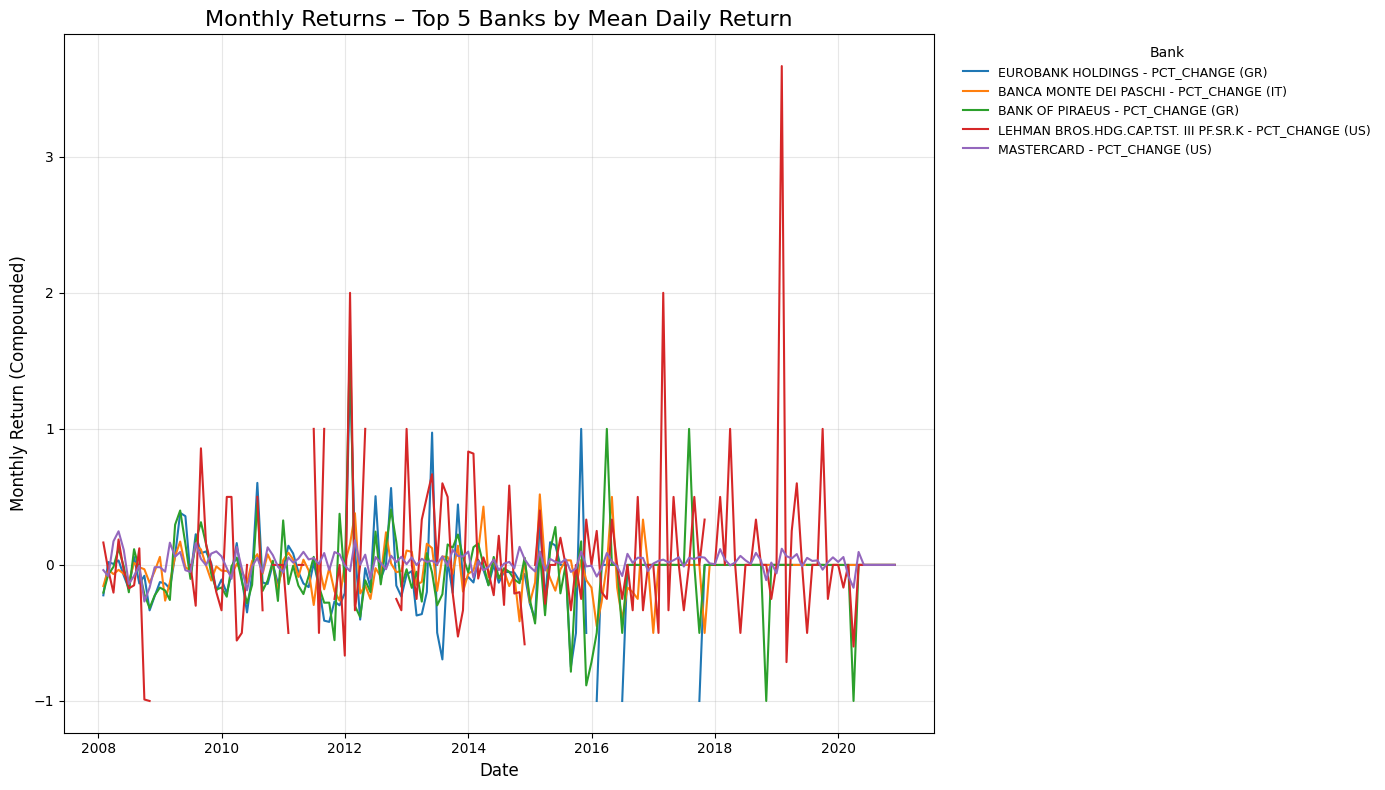

In [176]:
rdf = returns_df.copy()

if "date" in rdf.columns:
    rdf["date"] = pd.to_datetime(rdf["date"], errors="coerce")
    rdf = rdf.set_index("date")
else:
    rdf.index = pd.to_datetime(rdf.index, errors="coerce")

rdf = rdf[~rdf.index.isna()].sort_index()
rdf = rdf.select_dtypes(include="number")

# Compute mean returns and exclude 'MYBANK - PCT_CHANGE (NW)' if present
mean_returns = rdf.mean()
if "MYBANK - PCT_CHANGE (NW)" in mean_returns.index:
    mean_returns = mean_returns.drop("MYBANK - PCT_CHANGE (NW)")

# Find top 5 banks by mean daily return
top5_banks = mean_returns.sort_values(ascending=False).head(5).index
print("Top 5 Banks by Mean Return:", list(top5_banks))

# Monthly compounded returns
top5_returns = rdf[top5_banks]
monthly_returns = (1 + top5_returns).resample("M").prod() - 1

# Larger figure size
plt.figure(figsize=(14, 8))  # wider and taller plot

# Plot lines
for bank in top5_banks:
    plt.plot(monthly_returns.index, monthly_returns[bank], label=bank)

# Titles and labels
plt.title("Monthly Returns – Top 5 Banks by Mean Daily Return", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Monthly Return (Compounded)", fontsize=12)

# Smaller legend
plt.legend(
    title="Bank",
    title_fontsize=10,
    fontsize=9,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

# Grid and layout
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

- **Lehman Brothers Holdings** shows the highest volatility, with several large positive and negative spikes.

- **Eurobank Holdings and Bank of Piraeus** exhibit similar cyclical patterns, reflecting regional market behavior in Greece.

- **Banca Monte dei Paschi** shows moderate variation but remains closer to the zero-return line, indicating limited growth.

- **Mastercard** demonstrates the most stable performance, maintaining returns near zero with minimal fluctuation.

Across the period, banks’ returns show **no consistent upward trend**, reflecting a **volatile post-crisis environment**.

In [178]:
return_cols = [col for col in returns_df.columns if 'PCT_CHANGE' in col.upper()]
temp_returns_df = returns_df[return_cols].copy()

# Compute summary statistics
summary_stats = pd.DataFrame({
    'Mean': temp_returns_df.mean(),
    'Std': temp_returns_df.std(),
    'Skewness': temp_returns_df.skew(),
    'Kurtosis': temp_returns_df.kurt()
})

# Sort by mean return (optional)
summary_stats = summary_stats.sort_values(by='Mean', ascending=False)

summary_stats.round(3).head(10)

c:\Users\lasko\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\lasko\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1256: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean
c:\Users\lasko\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1344: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean


,Mean,Std,Skewness,Kurtosis
EUROBANK HOLDINGS - PCT_CHANGE (GR),inf,NaN,NaN,NaN
BANK OF PIRAEUS - PCT_CHANGE (GR),inf,NaN,NaN,NaN
BANCA MONTE DEI PASCHI - PCT_CHANGE (IT),inf,NaN,NaN,NaN
LEHMAN BROS.HDG.CAP.TST. III PF.SR.K - PCT_CHANGE (US),inf,NaN,NaN,NaN
MYBANK - PCT_CHANGE (NW),0.397,12.555,31.527,993.959
MASTERCARD - PCT_CHANGE (US),0.001,0.021,0.493,10.284
OTP BANKA SLOVENSKO - PCT_CHANGE (SX),0.001,0.061,8.861,221.467
FINECOBANK SPA - PCT_CHANGE (IT),0.001,0.020,-0.137,4.182
SVB FINANCIAL GROUP - PCT_CHANGE (US),0.001,0.027,0.015,8.485
AVANZA BANK HOLDING - PCT_CHANGE (SD),0.001,0.020,0.528,7.170


### Avg Returns vs Volatility

In [88]:
# --- 1. Compute metrics ---
mean_returns = returns_df.mean()                   # average daily return
volatility = returns_df.std()                      # daily volatility

# --- 2. Combine into a summary DataFrame ---
performance_summary = pd.DataFrame({
    'Average Daily Return': mean_returns,
    'Volatility (Std)': volatility
})

# Sort
performance_summary = performance_summary.sort_values(by='Volatility (Std)', ascending=False)

performance_summary.round(4).head(10)

,Average Daily Return,Volatility (Std)
CLOSE BROTHERS GROUP - RETURN,134928.7708,59597.3293
AFLAC - RETURN,147478.5885,57645.1551
STANDARD CHARTERED - RETURN,67667.9851,20574.5211
BANK OF IRELAND GROUP - RETURN,11939.7620,17911.2981
ROYAL BANK OF SCTL.GP. - RETURN,10591.2009,13231.2944
SVB FINANCIAL GROUP - RETURN,18107.7782,12274.8427
M&T BANK - RETURN,29183.2854,11997.0291
AIB GROUP - RETURN,4626.6217,11716.7825
ALLIANCE TRUST - RETURN,24160.3831,10452.4663
FIFTH THIRD BANCORP - RETURN,23130.8480,10086.3075


- Close Brothers Group and AFLAC exhibit the **highest volatility**, suggesting these banks experienced significant fluctuations in their daily returns. Despite high volatility, AFLAC achieved the highest average daily return, indicating strong performance but with elevated risk.

- Standard Chartered shows a **balance between return and volatility**, offering **moderate returns at lower risk** compared to the top two.

- Bank of Ireland Group and Royal Bank of Scotland Group deliver relatively **low returns and moderate volatility**, implying more stable but less profitable performance.

- M&T Bank and Alliance Trust maintain **lower volatility with decent returns**, potentially appealing to more risk-averse investors.

Overall, there’s **a clear risk–return tradeoff**: banks with **higher returns also tend to show higher volatility**.

In [89]:
performance_summary = performance_summary.sort_values(by='Average Daily Return', ascending=True)

# --- Display bottom 10 banks ---
bottom10 = performance_summary.round(4).head(10)
bottom10 = bottom10.sort_values(by='Average Daily Return', ascending=False)
print("Bottom 10 banks by average daily return:\n")
display(bottom10)

Bottom 10 banks by average daily return:



,Average Daily Return,Volatility (Std)
OTP BANKA SLOVENSKO - RETURN,67.1486,66.4426
OTP BANKA SLOVENSKO2 - RETURN,66.1849,69.4446
UNIONE DI BANCHE ITALIAN - RETURN,63.1980,31.1643
BANK OF CYPRUS HOLDING - RETURN,60.7877,22.0245
COMDIRECT BANK - RETURN,49.3775,17.6587
EFG INTERNATIONAL N - RETURN,30.6151,16.7359
BANCO BPM - RETURN,26.8989,27.7052
BANCA MONTE DEI PASCHI - RETURN,22.6478,28.8469
BANKIA - RETURN,12.4491,25.9073
LEHMAN BROS.HDG.CAP.TST. III PF.SR.K - RETURN,6.7450,24.4135


## Correlation Matrix for Top 10 Banks with the highest mean return over the researched period: 

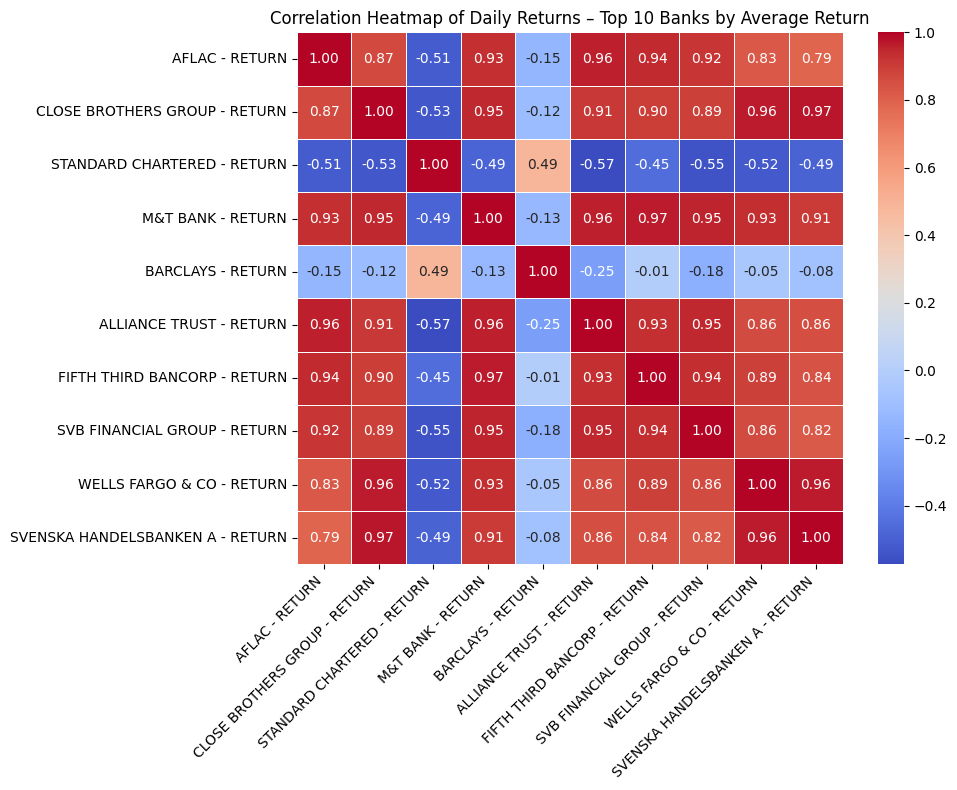

In [90]:
top10_banks = returns_df.mean().sort_values(ascending=False).head(10).index
top10_returns = returns_df[top10_banks]

# --- 3. Compute correlation matrix ---
corr_matrix = top10_returns.corr()

# --- 4. Plot correlation heatmap ---
plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    fmt=".2f"
)
plt.title("Correlation Heatmap of Daily Returns – Top 10 Banks by Average Return")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

- The heatmap shows **a strong clustering of positive correlations** among most of the top 10 banks — especially those with high average returns.

- Correlations range mostly between 0.80 and 0.97, meaning that **these banks’ daily returns tend to move in the same direction** on most days. This suggests that the banks are likely influenced by **similar macroeconomic and market factors**.
  
- Close Brothers Group – M&T Bank – Alliance Trust – Fifth Third Bancorp – SVB Financial Group form **a tight cluster**, with correlations typically above 0.90. These institutions likely share **exposure to similar regional or financial market conditions** (UK, US).
  
- Standard Chartered and Barclays stands out with **moderately negative correlations** with most others. They behave counter-cyclically relative to the cluster above — possibly due to their **greater exposure to different geographic focus**.

## Fama-French 5 factors model